# Part 2 - Ứng dụng Data Fitting vào dữ liệu thực tế

In [1]:
from pathlib import Path
import json
import math
import pickle
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "part2":
    ROOT = ROOT.parent

for path in (ROOT, ROOT / "part2", ROOT / "part1"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from config import RANDOM_STATE
from data_pipeline import (
    DataPipeline,
    load_dataset,
    train_test_split_frame,
    select_model_columns,
    write_eda_outputs,
    write_preprocessing_diagnostic_plots,
)
from model_comparison import run_model_comparison
from advanced_methods import run_kernel_ridge_bonus
from residual_analysis import residual_plots

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

DATA_PATH = ROOT / "part2" / "data" / "data.csv"
OUT_DIR = ROOT / "part2" / "output"
EDA_DIR = OUT_DIR / "eda"
DIAG_DIR = OUT_DIR / "diagnostics"
TARGET = "pl_rade"
ALPHA = 0.05

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Root: {ROOT}")
print(f"Data: {DATA_PATH}")
print(f"Output: {OUT_DIR}")
print(f"random_state = {RANDOM_STATE}, alpha = {ALPHA}")


Root: D:\Code\01_University\2526-HK2\TUDTK\Project2_DataFitting\group_3
Data: D:\Code\01_University\2526-HK2\TUDTK\Project2_DataFitting\group_3\part2\data\data.csv
Output: D:\Code\01_University\2526-HK2\TUDTK\Project2_DataFitting\group_3\part2\output
random_state = 42, alpha = 0.05


Cell setup import các module đã viết sẵn, cố định `random_state = 42` theo `config.py` và dùng mức ý nghĩa thống kê `alpha = 0.05`. Target của bài toán là `pl_rade`, tức bán kính hành tinh theo đơn vị bán kính Trái Đất.


## 1. Giới thiệu bài toán

Bài toán đặt ra là: từ các thông tin quan sát về quỹ đạo, transit, khối lượng hành tinh và đặc trưng sao chủ, ta có thể dự báo bán kính của ngoại hành tinh hay không?

Trong pipeline, target `pl_rade` được biến đổi thành `log_pl_rade = log(1 + pl_rade)`. Vì vậy các chỉ số RMSE, MAE và R2 chính được đọc trên thang log, còn phần Prediction sẽ biến đổi ngược về thang gốc để tính MAPE dễ diễn giải hơn.


## 2. Hiểu dữ liệu (Data Understanding)

### 2.1 Mô tả dữ liệu


In [2]:
source_raw = load_dataset(DATA_PATH)
planet_raw = select_model_columns(source_raw, target=TARGET)

print("Shape dữ liệu chuẩn full-column:", source_raw.shape)
print("Shape sau schema filter:", planet_raw.shape)
display(planet_raw.head())

variable_table = pd.DataFrame(
    [
        ("pl_orbper", "Chu kỳ quỹ đạo", "ngày"),
        ("pl_orbsmax", "Bán trục lớn quỹ đạo", "AU"),
        ("pl_orbeccen", "Độ lệch tâm quỹ đạo", "không đơn vị"),
        ("pl_trandur", "Thời lượng transit", "giờ"),
        ("pl_trandep", "Độ sâu transit", "tỷ lệ/đơn vị dữ liệu gốc"),
        ("pl_imppar", "Impact parameter", "không đơn vị"),
        ("pl_eqt", "Nhiệt độ cân bằng hành tinh", "K"),
        ("pl_insol", "Thông lượng bức xạ nhận được", "so với Trái Đất"),
        ("pl_bmasse", "Khối lượng hành tinh", "khối lượng Trái Đất"),
        ("pl_rade", "Bán kính hành tinh - biến mục tiêu", "bán kính Trái Đất"),
        ("st_teff", "Nhiệt độ hiệu dụng sao chủ", "K"),
        ("st_rad", "Bán kính sao chủ", "bán kính Mặt Trời"),
        ("st_mass", "Khối lượng sao chủ", "khối lượng Mặt Trời"),
        ("st_met", "Kim loại tính của sao chủ", "dex"),
        ("st_logg", "Log-g của sao chủ", "log10(cm/s^2)"),
        ("sy_dist", "Khoảng cách tới hệ sao", "parsec"),
    ],
    columns=["Biến", "Ý nghĩa", "Đơn vị/ghi chú"],
)
display(variable_table)


Shape dữ liệu chuẩn full-column: (4636, 320)
Shape sau schema filter: (4636, 16)


,pl_orbper,pl_orbsmax,pl_orbeccen,pl_trandur,pl_trandep,pl_imppar,pl_eqt,pl_insol,pl_bmasse,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,pl_rade
0,1.003934,0.01750,0.0,1.4562,0.04911,0.023,1419.0,1039.697,3.570,4971.0,0.750,0.790,-0.05,4.600,820.905,1.710000
1,8.172400,0.07790,0.0,3.9020,0.08643,0.942,858.0,127.950,11.000,5705.0,0.905,0.943,-0.06,4.499,1061.770,3.323214
2,6.283855,0.06865,0.0,4.1240,0.00357,0.101,1108.0,470.862,0.437,6022.0,1.230,1.120,0.07,4.310,493.175,0.800000
3,3.173917,0.04641,0.0,3.5066,0.03030,0.629,1655.0,2381.770,10.100,6747.0,1.810,1.490,0.08,4.090,1318.050,3.150000
4,56.358501,0.26980,0.0,6.9270,0.25596,0.906,419.0,7.290,18.700,5446.0,0.821,0.824,-0.20,4.525,962.888,4.540605


,Biến,Ý nghĩa,Đơn vị/ghi chú
0,pl_orbper,Chu kỳ quỹ đạo,ngày
1,pl_orbsmax,Bán trục lớn quỹ đạo,AU
2,pl_orbeccen,Độ lệch tâm quỹ đạo,không đơn vị
3,pl_trandur,Thời lượng transit,giờ
4,pl_trandep,Độ sâu transit,tỷ lệ/đơn vị dữ liệu gốc
5,pl_imppar,Impact parameter,không đơn vị
6,pl_eqt,Nhiệt độ cân bằng hành tinh,K
7,pl_insol,Thông lượng bức xạ nhận được,so với Trái Đất
8,pl_bmasse,Khối lượng hành tinh,khối lượng Trái Đất
9,pl_rade,Bán kính hành tinh - biến mục tiêu,bán kính Trái Đất


`data.csv` là dữ liệu chuẩn của Part 2 với 4636 dòng và 320 cột gốc từ NASA Exoplanet Archive. Notebook và pipeline không đưa toàn bộ 320 cột vào mô hình; bước schema filter giữ 16 biến vật lý có ý nghĩa trực tiếp cho bài toán dự báo `pl_rade`, gồm nhóm quỹ đạo, transit, năng lượng nhận từ sao chủ, khối lượng hành tinh, đặc trưng sao chủ và khoảng cách hệ sao.


### Động lực vật lý 
Cấu trúc nên một hành tinh khí khổng lồ (Gas Giant) khác đáng kể so với một hành tinh đá (Terrestrial) hoặc Super-Earth. Nếu giữ nguyên toàn bộ tập dữ liệu, mặt phẳng hồi quy sẽ phải đồng thời mô tả nhiều chế độ vật lý khác nhau, dễ bị nhiễu bởi hiện tượng phương sai không đồng nhất do chênh lệch quy mô quá lớn giữa các nhóm hành tinh. Vì vậy, nhóm tối ưu hóa khả năng nội suy cục bộ của mô hình bằng cách chỉ giữ nhóm hành tinh đá và Super-Earth theo ngưỡng phân rã Fulton (Fulton Gap): bán kính không vượt quá 1.6R⊕ và khối lượng không vượt quá 10M⊕. Thao tác này được thực hiện trong pipeline ngay sau schema filter và trước train/test split, MICE, VIF cũng như chuẩn hóa, để bộ nội suy và các tham số mean/std chỉ học phân phối của riêng nhóm hành tinh này.


In [3]:
planet = planet_raw[(planet_raw["pl_rade"] <= 1.6) & (planet_raw["pl_bmasse"] <= 10)].dropna(subset=[TARGET]).reset_index(drop=True)
print("Shape sau domain restriction:", planet.shape)
display(
    pd.DataFrame(
        {
            "Giai đoạn": ["data.csv", "Sau schema filter", "Sau domain restriction"],
            "Số dòng": [len(source_raw), len(planet_raw), len(planet)],
            "Số cột": [source_raw.shape[1], planet_raw.shape[1], planet.shape[1]],
        }
    )
)


Shape sau domain restriction: (1084, 16)


,Giai đoạn,Số dòng,Số cột
0,data.csv,4636,320
1,Sau schema filter,4636,16
2,Sau domain restriction,1084,16


Notebook giữ nhóm hành tinh đá/Super-Earth với `pl_rade <= 1.6` và `pl_bmasse <= 10`.


### 2.2 Khám phá dữ liệu (EDA)


In [4]:
eda_paths = write_eda_outputs(planet, target=TARGET, output_dir=EDA_DIR)
describe_table = pd.read_csv(EDA_DIR / "describe_numeric.csv", index_col=0)
display(describe_table.round(4))


,count,mean,std,min,25%,50%,75%,max
pl_orbper,1084.0,8.4750,13.7854,0.1769,2.4698,4.7227,9.4638,199.6688
pl_orbsmax,998.0,0.0679,0.0571,0.0050,0.0331,0.0526,0.0850,0.6193
pl_orbeccen,939.0,0.0154,0.0617,0.0000,0.0000,0.0000,0.0000,0.8800
pl_trandur,1060.0,2.7193,1.6231,0.2920,1.6308,2.3765,3.3292,15.7220
pl_trandep,1033.0,0.0405,0.0865,0.0012,0.0114,0.0204,0.0354,1.6536
pl_imppar,1040.0,0.3513,0.2598,-0.1300,0.1352,0.2943,0.5100,1.2325
pl_eqt,1005.0,999.7255,431.5893,171.7000,698.0000,954.0000,1214.0000,3186.0000
pl_insol,981.0,520.5439,931.4663,0.1440,50.4270,182.3750,518.4370,8385.9000
pl_bmasse,1084.0,2.1245,1.2501,0.0364,1.2800,2.1800,2.7600,10.0000
st_teff,1084.0,5132.7154,897.5846,2566.0000,4658.2500,5382.0000,5815.0000,6681.0000


Bảng thống kê mô tả cho thấy dữ liệu có nhiều thang đo khác nhau. Các biến như `pl_orbper`, `pl_insol`, `sy_dist` có khoảng giá trị rộng và đuôi phải dài; target `pl_rade` đã bị giới hạn trong miền hành tinh đá/Super-Earth nên dao động hẹp hơn.


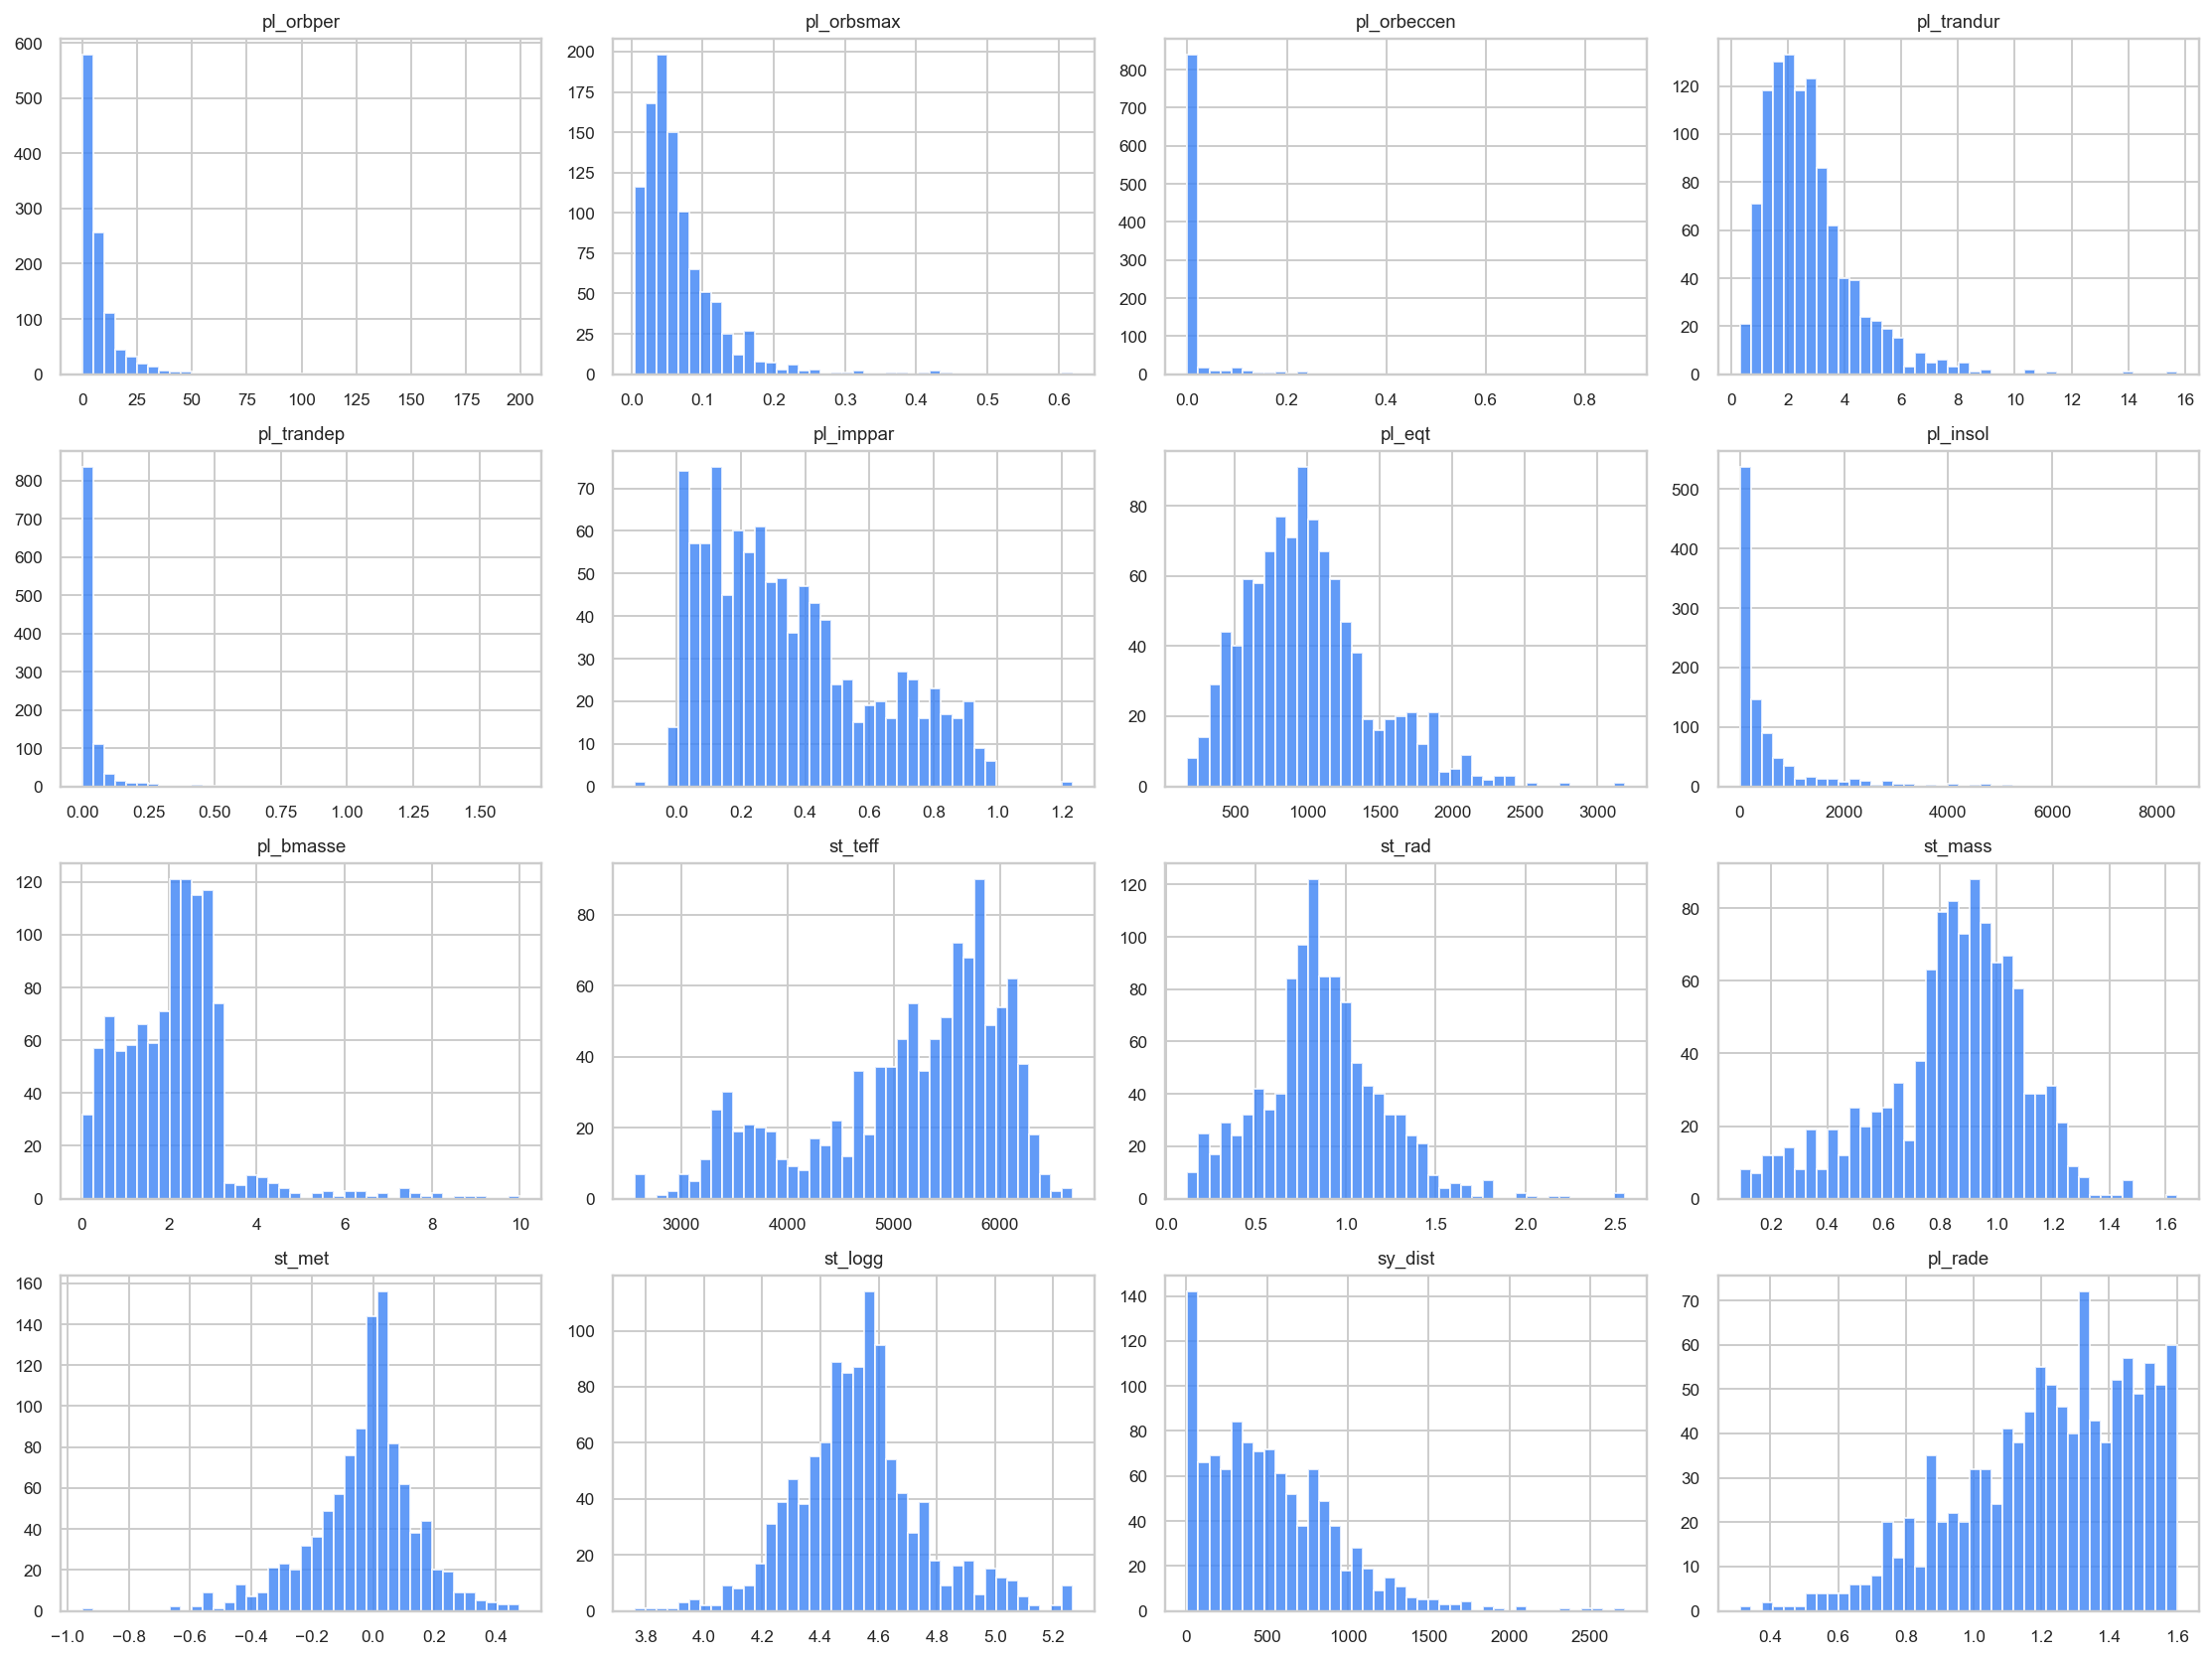

In [5]:
display(Image(filename=str(EDA_DIR / "histograms.png")))


Histogram xác nhận nhiều biến bị lệch phải mạnh, đặc biệt là các biến quỹ đạo/năng lượng và khoảng cách hệ sao. Đây là lý do pipeline dùng log-transform cho các biến có thang đo dương và phân phối lệch.


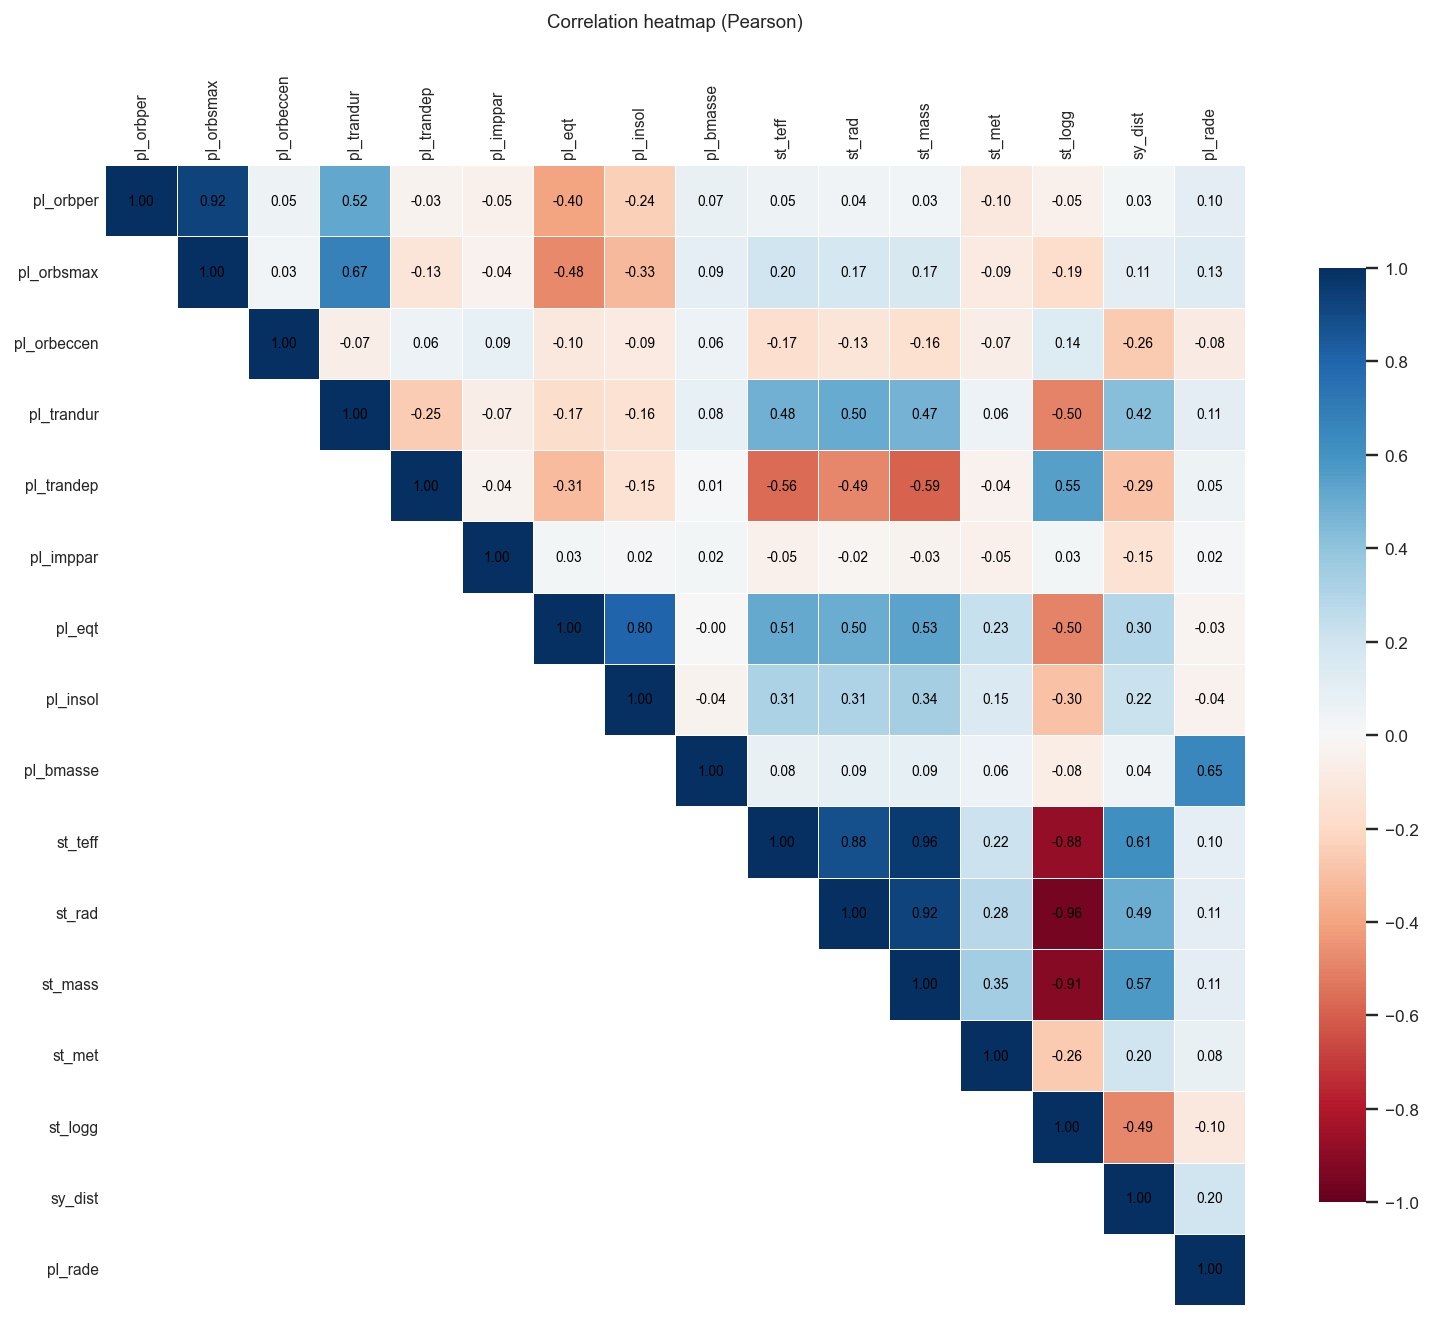

In [6]:
display(Image(filename=str(EDA_DIR / "correlation_heatmap.png")))


Heatmap tương quan cho thấy một số nhóm biến có quan hệ tuyến tính mạnh, ví dụ nhóm quỹ đạo/năng lượng. Vì các biến tương quan cao có thể làm hệ số OLS kém ổn định, pipeline cần bước lọc đa cộng tuyến bằng VIF trước khi fit mô hình cuối.


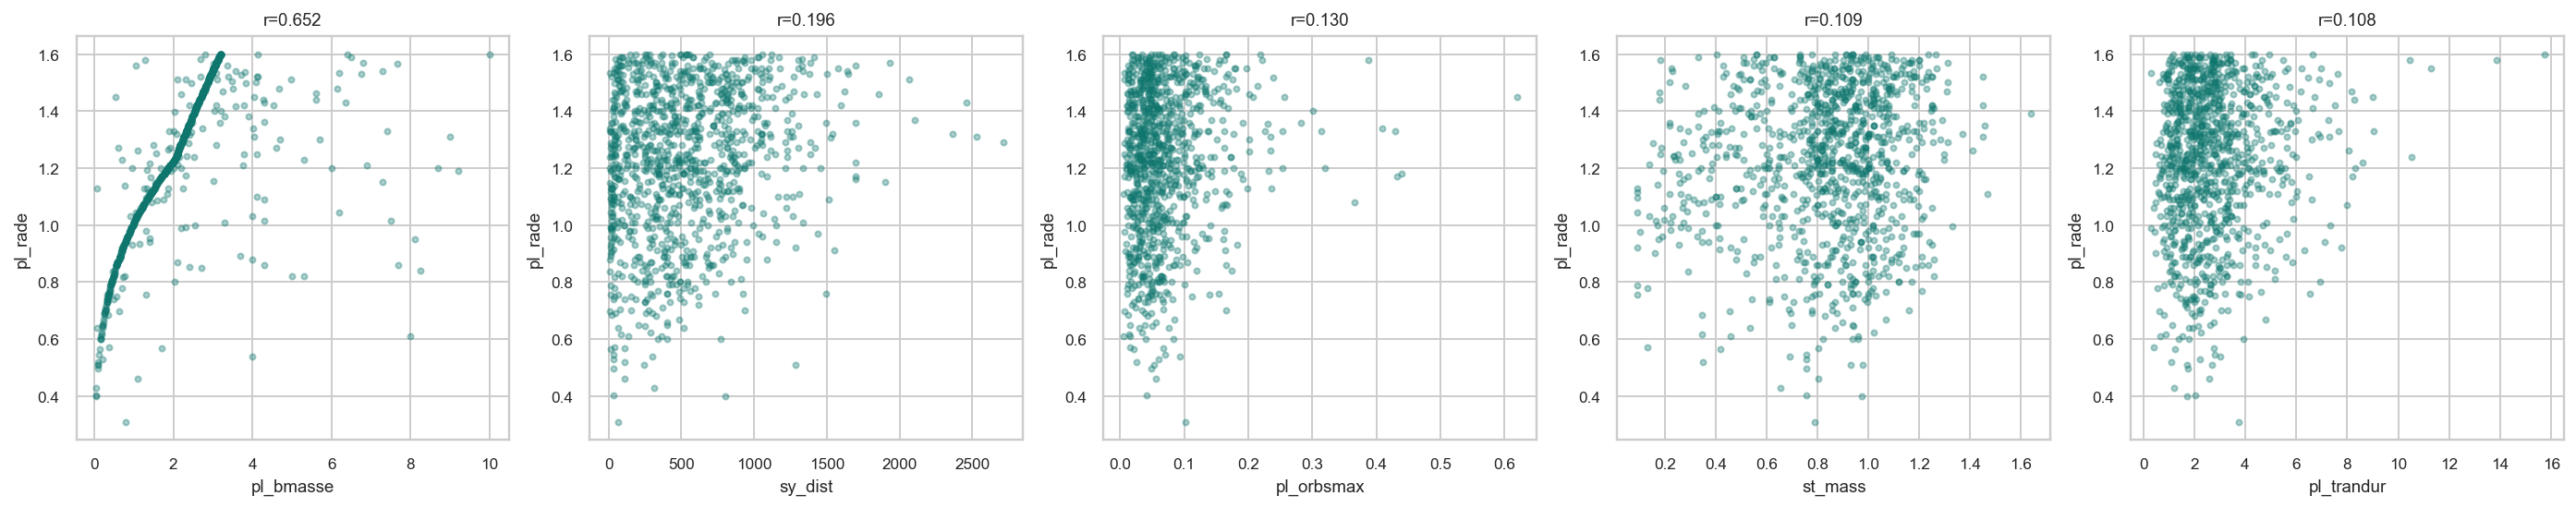

In [7]:
display(Image(filename=str(EDA_DIR / "scatter_top5_target.png")))


Các scatter plot giữa target và những biến tương quan cao nhất cho thấy có tín hiệu dự báo rõ, nhưng quan hệ không hoàn toàn tuyến tính và còn nhiều điểm nhiễu. Điều này giải thích vì sao mô hình tuyến tính đạt R2 tốt nhưng vẫn chưa giải thích toàn bộ biến thiên của bán kính hành tinh.


### 2.3 Kiểm tra chất lượng dữ liệu


In [8]:
duplicate_count = int(planet.duplicated().sum())
missing_table = pd.read_csv(EDA_DIR / "missing_values.csv")

print(f"Số dòng duplicate: {duplicate_count}/{len(planet)}")
display(missing_table[missing_table["missing_count"] > 0].head(12))

numeric_cols = planet.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(planet[col].dropna(), vert=True, patch_artist=True)
    ax.set_title(col)
    ax.set_ylabel("Value")
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)
fig.suptitle("Boxplot trước xử lý outlier", y=1.02)
fig.tight_layout()
plt.show()


Số dòng duplicate: 0/1084


,column,missing_count,missing_percent,dtype
0,pl_orbeccen,145,13.376,float64
1,pl_insol,103,9.502,float64
2,pl_orbsmax,86,7.934,float64
3,pl_eqt,79,7.288,float64
4,pl_trandep,51,4.705,float64
5,pl_imppar,44,4.059,float64
6,st_met,35,3.229,float64
7,pl_trandur,24,2.214,float64
8,sy_dist,6,0.554,float64


C:\Users\Hakhoi\AppData\Local\Temp\ipykernel_25360\3146370555.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Không có dòng trùng lặp sau domain restriction. Missing values xuất hiện ở nhiều biến, nhiều nhất là `pl_orbeccen`, `pl_insol`, `pl_orbsmax` và `pl_eqt`, nên xóa dòng sẽ làm mất dữ liệu và có thể gây lệch mẫu. Boxplot cũng cho thấy nhiều giá trị cực trị; trong bối cảnh thiên văn, các điểm này có thể là quan sát thật nên nhóm xây dựng pipeline giảm ảnh hưởng bằng log-transform/Winsorization thay vì xóa cứng.


## 3. Chuẩn bị dữ liệu (Data Preparation)

### 3.1 Lựa chọn biến

Từ dữ liệu NASA gốc, nhóm giữ các biến có ý nghĩa dự báo trực tiếp cho bán kính hành tinh: nhóm quỹ đạo, transit, năng lượng, khối lượng hành tinh, đặc trưng sao chủ và khoảng cách hệ sao. Các cột metadata, sai số đo lường, cờ giới hạn và định danh không được đưa vào mô hình vì không đại diện cho đặc tính vật lý độc lập của hành tinh.

Trong pipeline, `st_mass` và `st_logg` được loại sớm để giảm trùng lặp thông tin với các biến sao chủ khác; sau đó VIF tiếp tục loại các biến đa cộng tuyến còn lại.


### 3.2 Pipeline tiền xử lý


In [9]:
train_raw, test_raw = train_test_split_frame(planet, test_size=0.2, random_state=RANDOM_STATE)

pipeline = DataPipeline(target=TARGET)
X_train, y_train = pipeline.fit_transform(train_raw)
X_test, y_test = pipeline.transform(test_raw, include_target=True)

preprocessed = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train.reset_index(drop=True),
    "y_test": y_test.reset_index(drop=True),
    "feature_names": pipeline.feature_names_,
    "target": TARGET,
    "target_transformed": pipeline.target_transformed_,
    "metadata": pipeline.metadata(),
    "eda_paths": eda_paths,
}
preprocessed["metadata"].update(
    {
        "source_data_path": str(DATA_PATH),
        "source_data_shape": list(source_raw.shape),
        "model_input_shape_before_domain_filter": list(planet_raw.shape),
        "schema_filter_columns": list(planet_raw.columns),
        "schema_filter_dropped_columns": int(source_raw.shape[1] - planet_raw.shape[1]),
    }
)

with (OUT_DIR / "preprocessed.pkl").open("wb") as f:
    pickle.dump(preprocessed, f)
(OUT_DIR / "preprocessing_metadata.json").write_text(json.dumps(preprocessed["metadata"], indent=2), encoding="utf-8")
if pipeline.missing_report_ is not None:
    pipeline.missing_report_.to_csv(OUT_DIR / "missing_report_after_transforms.csv", index=False)

prep_plot_paths = write_preprocessing_diagnostic_plots(train_raw, pipeline, DIAG_DIR)

print("Train/Test raw:", train_raw.shape, test_raw.shape)
print("Train/Test sau pipeline:", X_train.shape, X_test.shape)
print("Target transform:", TARGET, "->", pipeline.target_transformed_)
print("Final features:", pipeline.feature_names_)
print("VIF dropped columns:", pipeline.vif_drop_columns_)


[DataPipeline] Raw data: rows=867, columns=16, target='pl_rade', missing target rows=0
[DataPipeline] After target cleanup and log-transform: rows=867, features=15, target='log_pl_rade'

[DataPipeline] Log-transform effect on skewness and scale
    source        created  missing  min_before  max_before  skew_before  skew_after
 pl_orbper  log_pl_orbper        0    0.176891   199.66876     6.861484    0.490095
pl_orbsmax log_pl_orbsmax       73    0.005000     0.61930     3.231263    2.594798
pl_trandep log_pl_trandep       40    0.001220     1.65360    10.180175    6.952230
  pl_insol   log_pl_insol       83    0.144000  8385.90000     3.959605   -0.381478
 pl_bmasse  log_pl_bmasse        0    0.036400    10.00000     1.769409   -0.271630
    pl_eqt     log_pl_eqt       67  171.700000  3186.00000     0.878810   -0.476649
   sy_dist    log_sy_dist        6    6.869290  2712.58000     1.182893   -1.150935
   pl_rade    log_pl_rade        0    0.309800     1.60000    -0.692968   -0.991840

Pipeline được fit trên train set và chỉ transform test set bằng các tham số học từ train để tránh data leakage. Các bước chính gồm log-transform target/predictors, Winsorization, MICE imputation, lọc VIF và chuẩn hóa feature.


,source,created,missing,min_before,max_before,skew_before,skew_after
0,pl_orbper,log_pl_orbper,0,0.1769,199.6688,6.8615,0.4901
1,pl_orbsmax,log_pl_orbsmax,73,0.0050,0.6193,3.2313,2.5948
2,pl_trandep,log_pl_trandep,40,0.0012,1.6536,10.1802,6.9522
3,pl_insol,log_pl_insol,83,0.1440,8385.9000,3.9596,-0.3815
4,pl_bmasse,log_pl_bmasse,0,0.0364,10.0000,1.7694,-0.2716
5,pl_eqt,log_pl_eqt,67,171.7000,3186.0000,0.8788,-0.4766
6,sy_dist,log_sy_dist,6,6.8693,2712.5800,1.1829,-1.1509
7,pl_rade,log_pl_rade,0,0.3098,1.6000,-0.6930,-0.9918


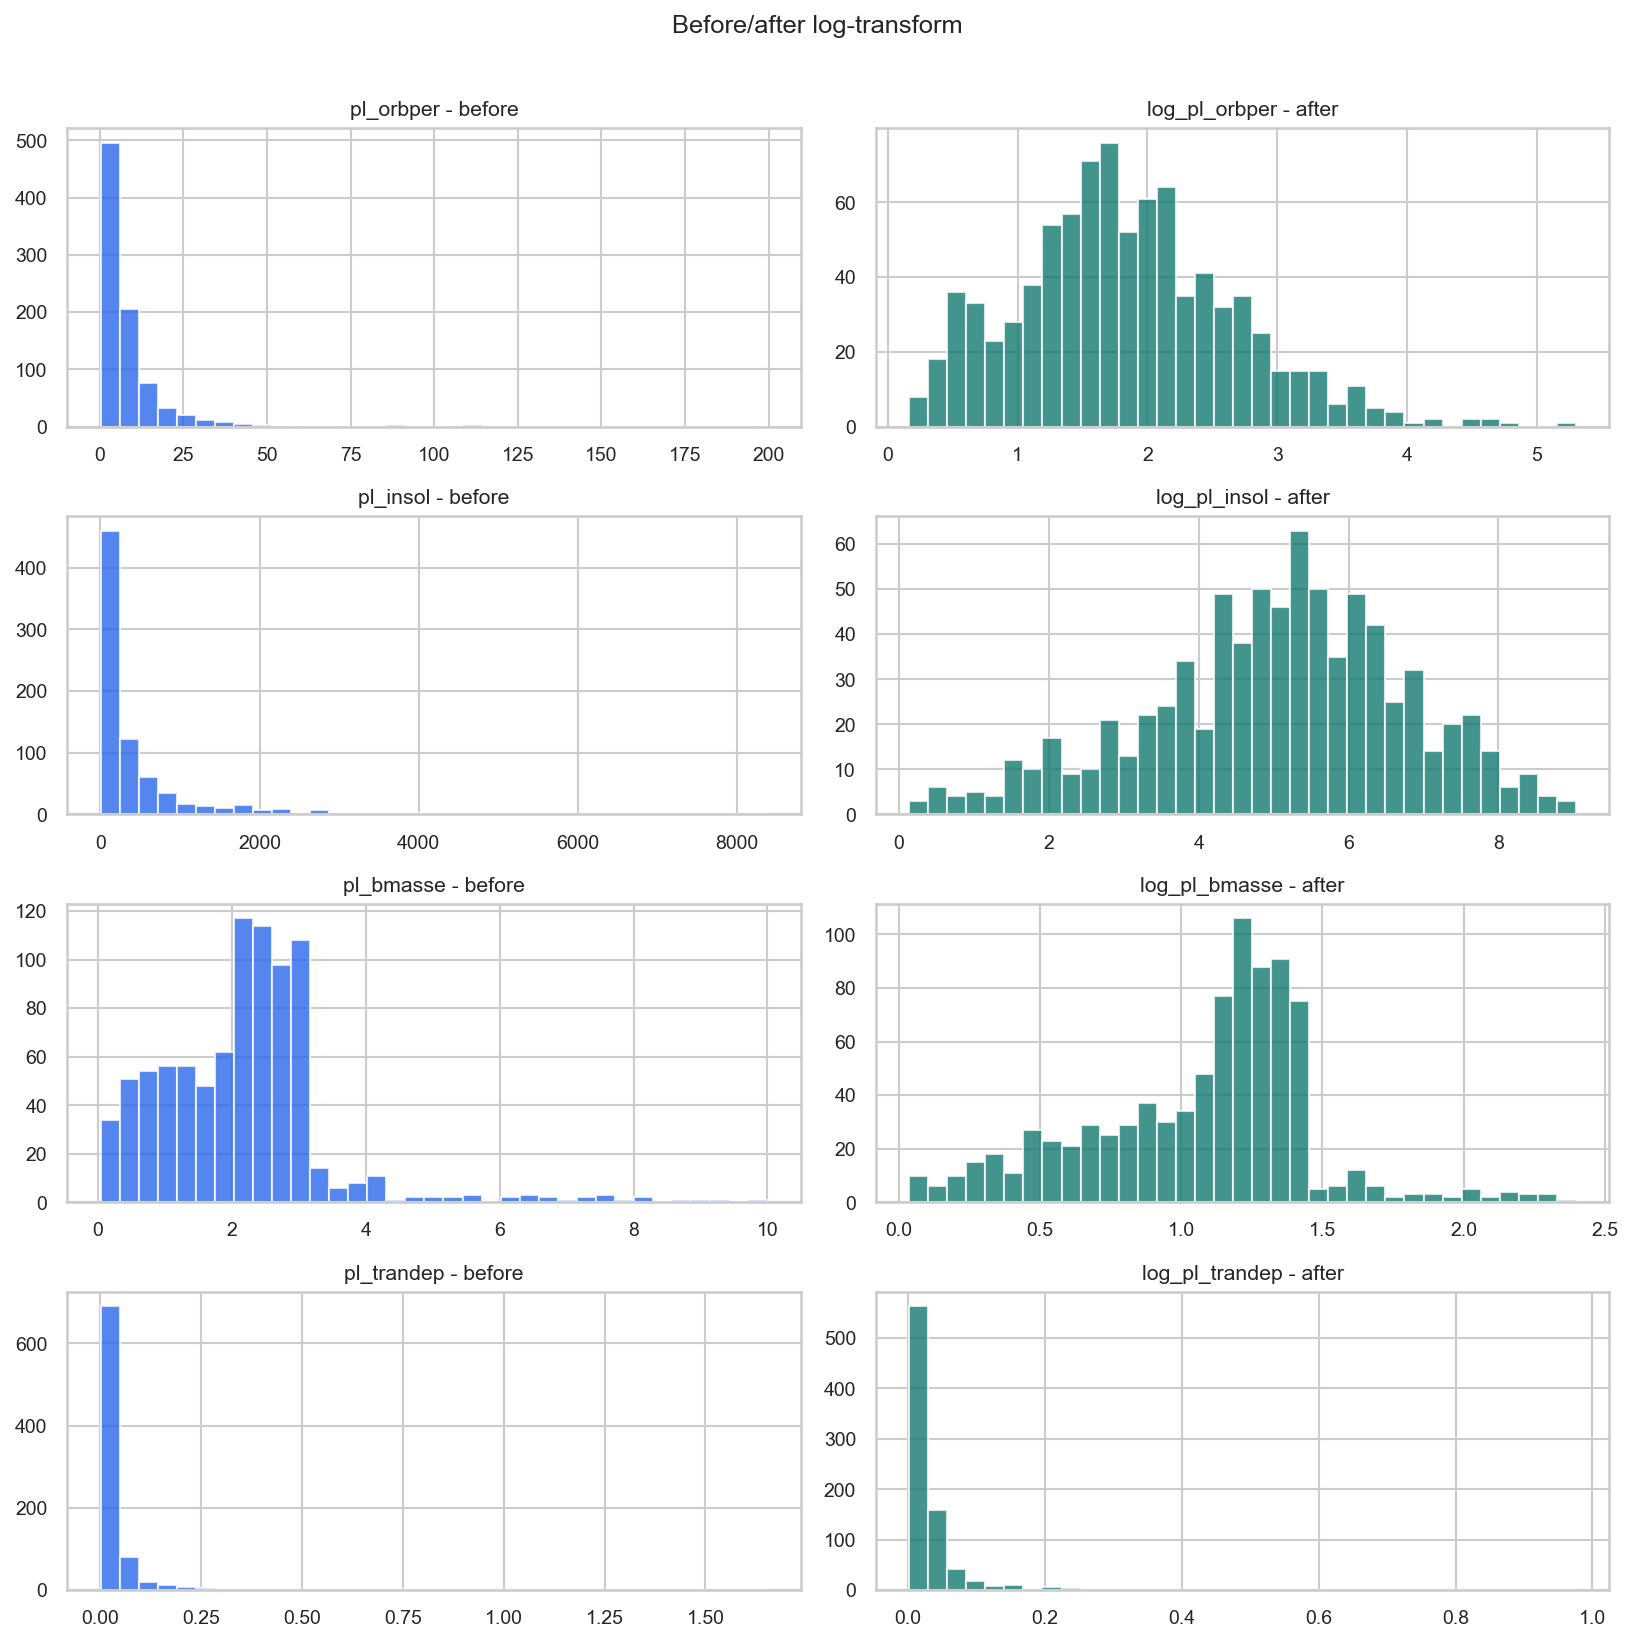

In [10]:
display(pd.DataFrame(pipeline.log_transform_report_).round(4))
display(Image(filename=str(DIAG_DIR / "log_transform_before_after.png")))


Log-transform làm giảm độ lệch và nén các biến có đuôi phải dài. Với target, mô hình học `log(1 + pl_rade)`, giúp phần dư ổn định hơn so với hồi quy trực tiếp trên thang gốc.


,column,p01,p99,below_p01,above_p99,clipped_total,clipped_%
0,pl_orbeccen,0.0000,0.2994,0,8,8,1.061
1,pl_trandur,0.6241,8.1895,9,9,18,2.120
2,pl_imppar,0.0040,0.9395,9,9,18,2.179
3,st_rad,0.1963,1.7887,9,9,18,2.076


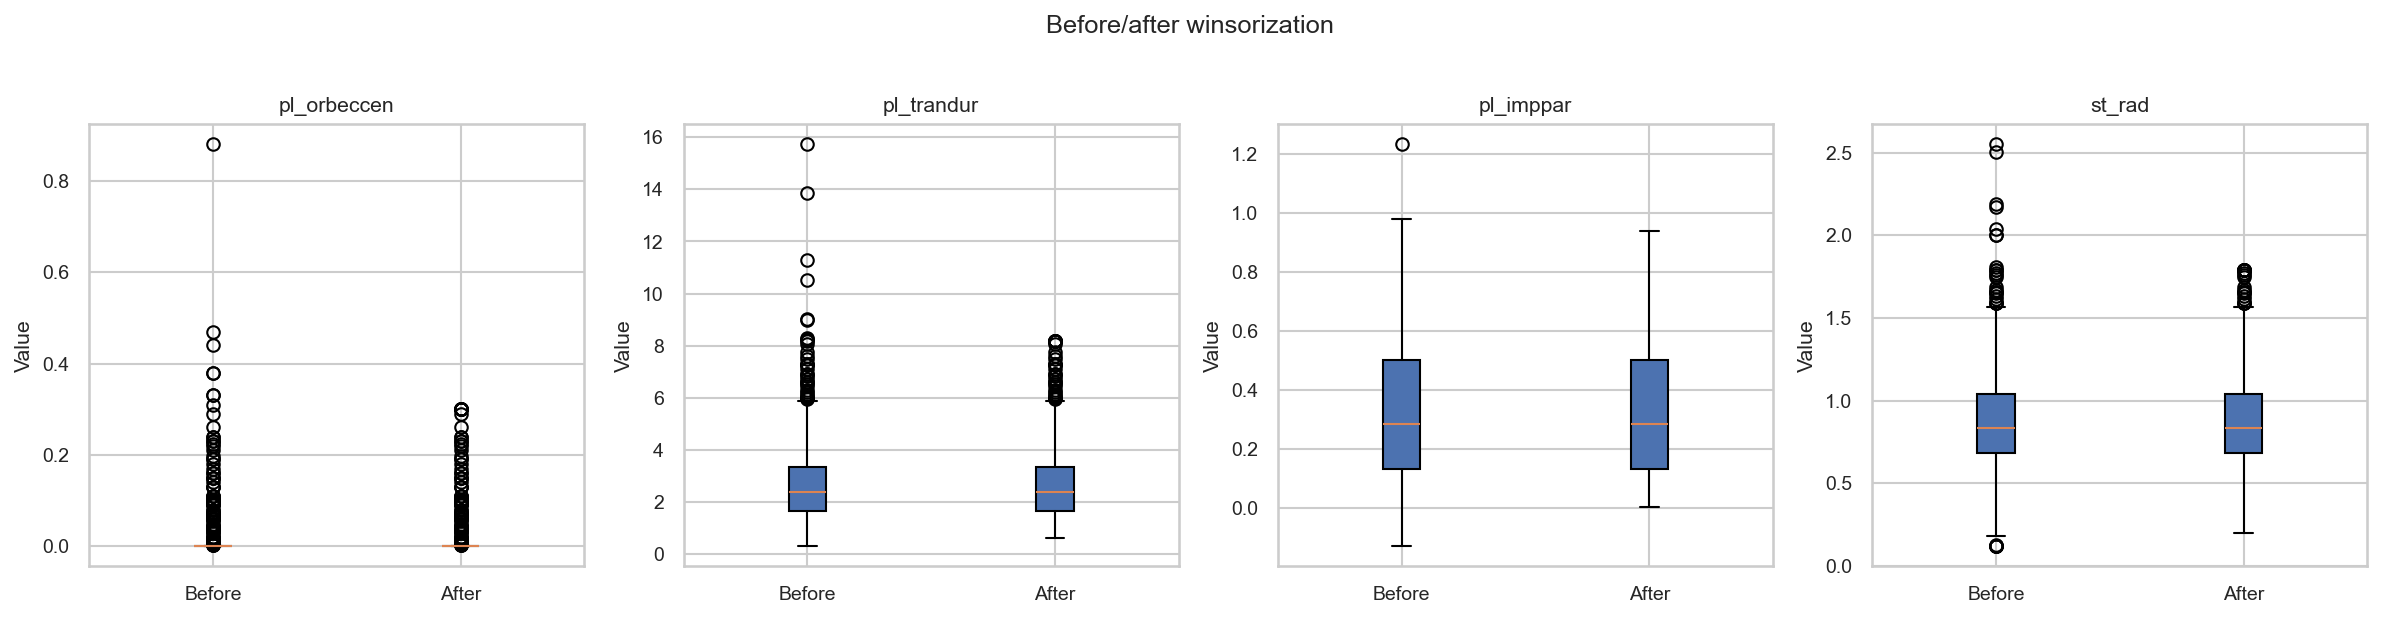

In [11]:
display(pd.DataFrame(pipeline.winsor_report_).round(4))
display(Image(filename=str(DIAG_DIR / "winsorization_before_after.png")))


Winsorization giới hạn các giá trị quá cực đoan theo ngưỡng học từ train set. Cách này giữ lại quan sát nhưng giảm ảnh hưởng đòn bẩy của outlier lên hệ số hồi quy.


,column,missing,missing_%,initial_median,observed_mean,imputed_mean,imputed_std,imputed_min,imputed_max
0,pl_orbeccen,113,13.033,0.0000,0.0137,0.0335,0.0214,-0.0180,0.0910
1,log_pl_insol,83,9.573,5.2075,5.0362,5.3324,1.5559,1.9675,7.9496
2,log_pl_orbsmax,73,8.420,0.0522,0.0647,0.0450,0.0407,-0.0215,0.1597
3,log_pl_eqt,67,7.728,6.8570,6.8064,6.8057,0.4578,5.7435,7.5700
4,pl_imppar,41,4.729,0.2847,0.3465,0.3941,0.0595,0.2723,0.5742
5,log_pl_trandep,40,4.614,0.0205,0.0366,0.0470,0.0401,-0.0059,0.1552
6,st_met,24,2.768,0.0000,-0.0252,-0.0971,0.0399,-0.1722,-0.0191
7,pl_trandur,18,2.076,2.3720,2.6998,2.1278,1.0642,0.6039,4.4915
8,log_sy_dist,6,0.692,6.1044,5.8306,5.1439,0.9911,3.1453,5.9841


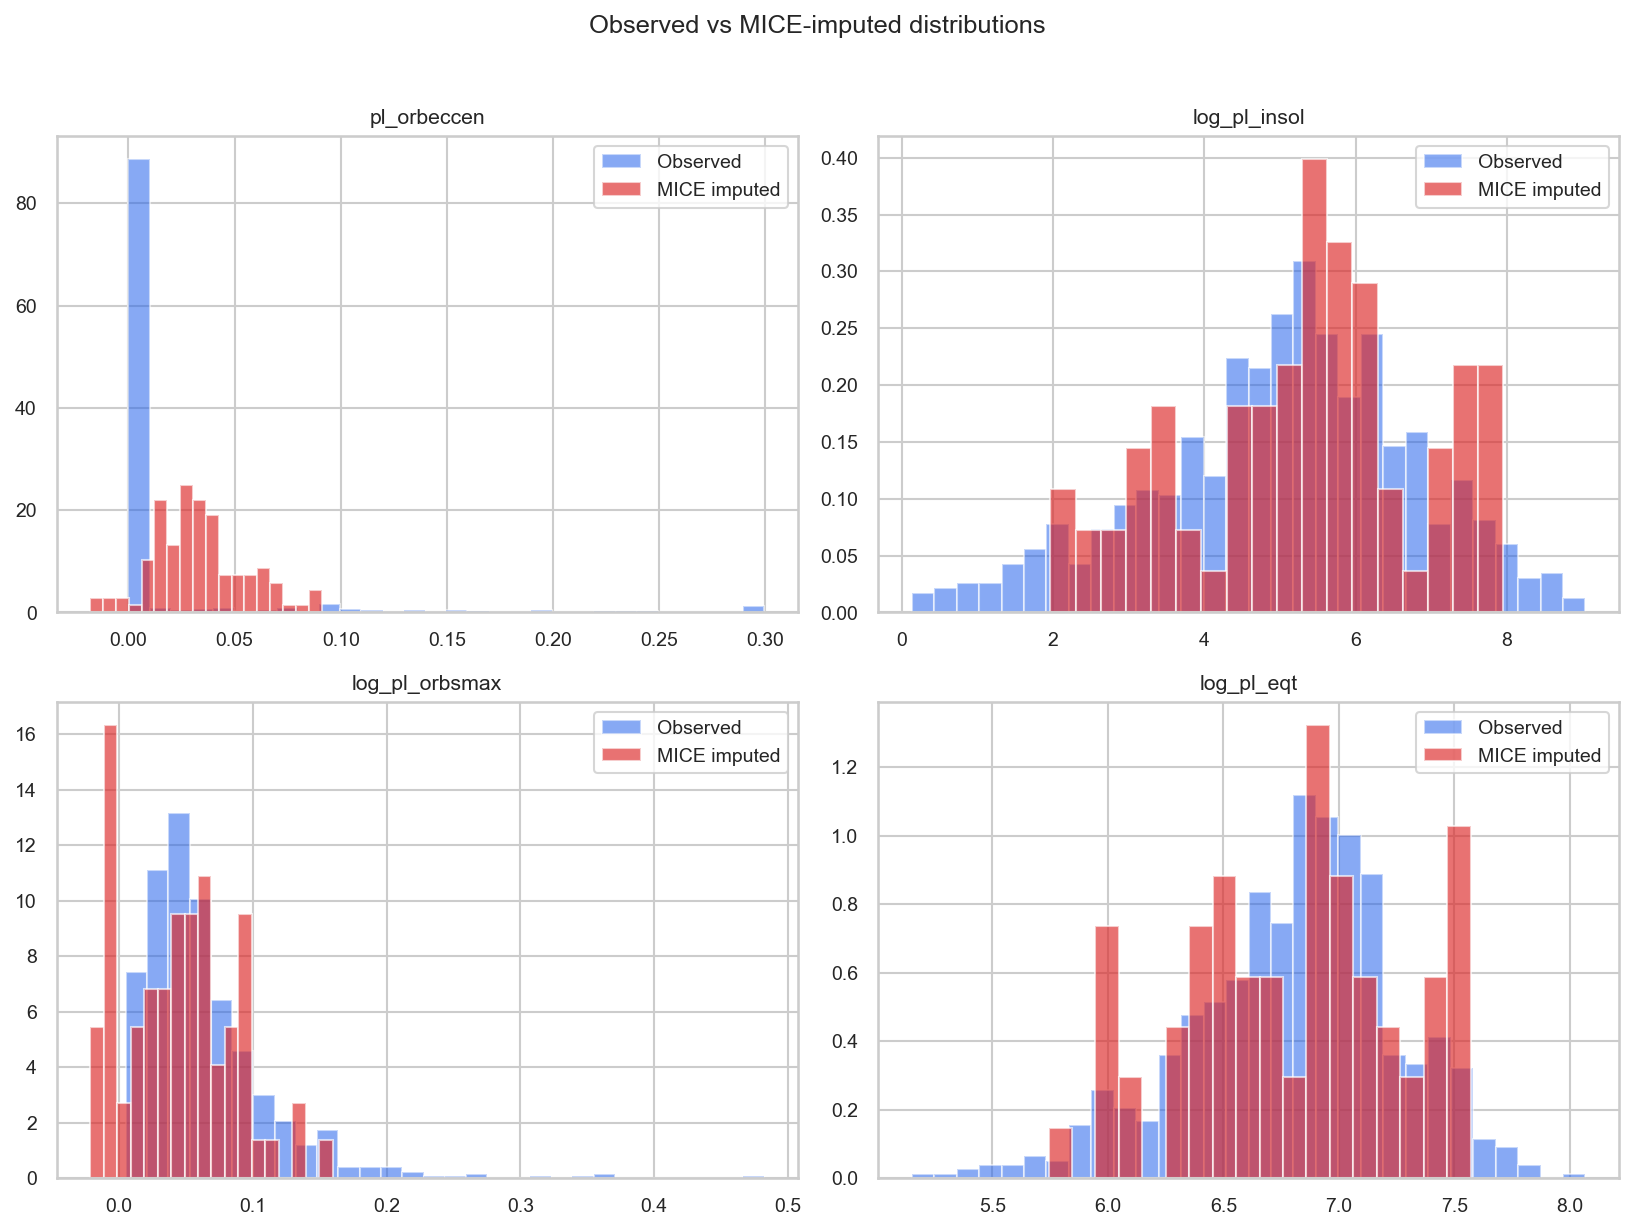

In [12]:
imputation_report = pd.DataFrame(pipeline.imputation_report_)
display(imputation_report.round(4))
if (DIAG_DIR / "mice_observed_vs_imputed.png").exists():
    display(Image(filename=str(DIAG_DIR / "mice_observed_vs_imputed.png")))
else:
    print("Không có hình MICE vì tập train sau các bước trước không còn cột cần impute.")


MICE được dùng để điền missing values dựa trên quan hệ giữa các biến thay vì thay thế toàn bộ bằng một hằng số đơn giản. Bảng so sánh observed/imputed giúp kiểm tra giá trị điền vào có cùng miền phân phối hợp lý với dữ liệu quan sát hay không.


VIF history:


,feature,vif
0,log_pl_orbper,43.137446
1,log_pl_eqt,20.451394
2,st_teff,9.257044


Final VIF:


,feature,VIF
3,st_teff,9.2570
4,st_rad,5.9915
8,log_pl_insol,5.8778
6,log_pl_orbsmax,4.6054
1,pl_trandur,3.0931
10,log_sy_dist,2.8147
7,log_pl_trandep,1.8730
0,pl_orbeccen,1.2736
5,st_met,1.1861
2,pl_imppar,1.0732


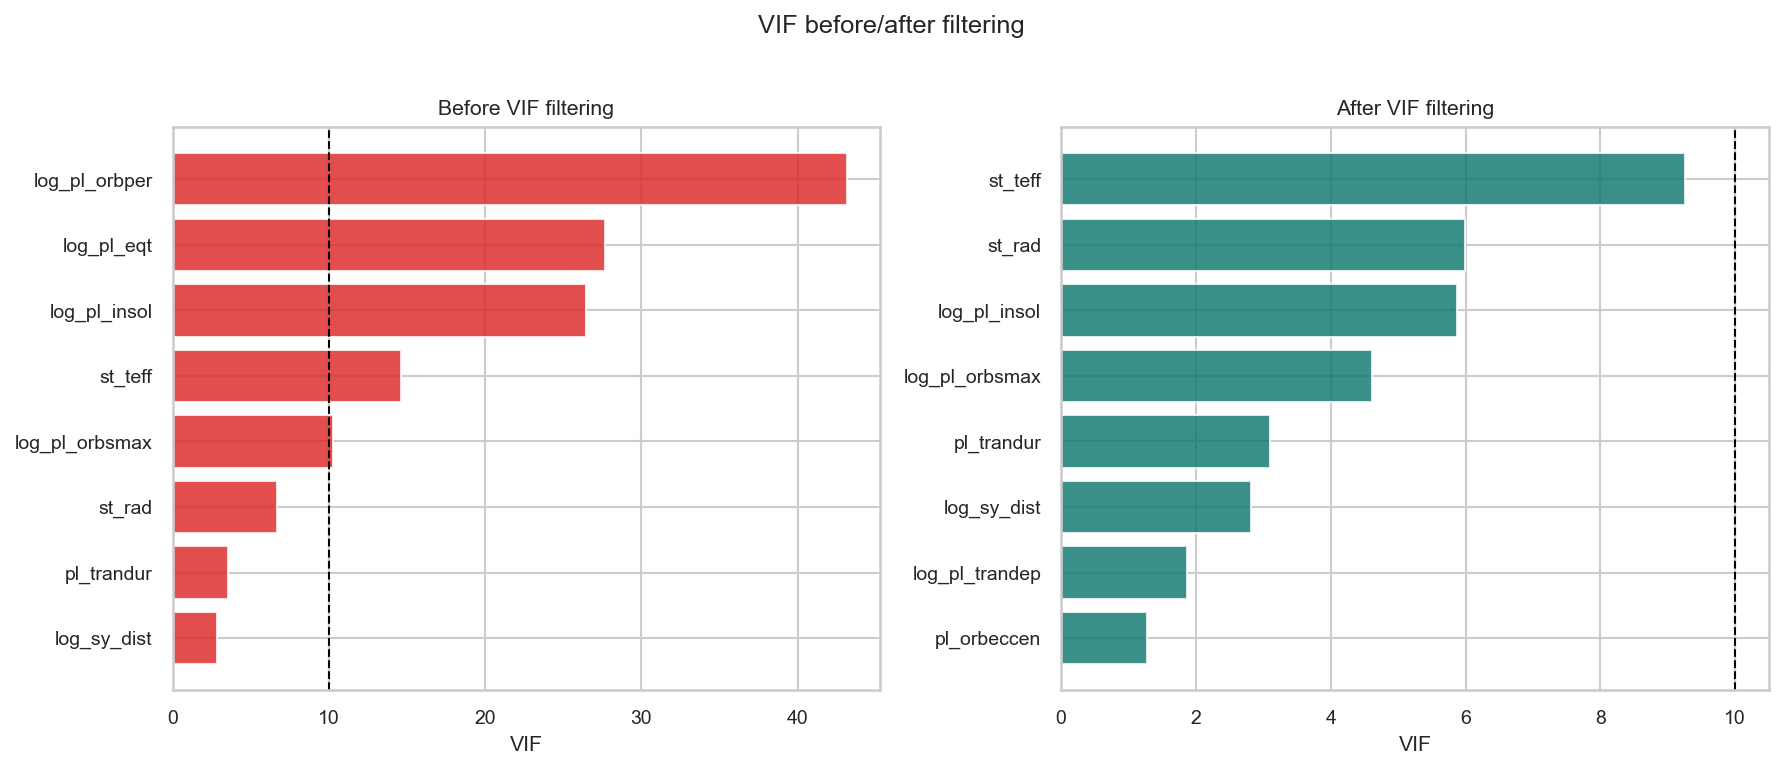

In [13]:
vif_history = pd.DataFrame(pipeline.vif_history_)
final_vif = pd.DataFrame(
    {"feature": list(pipeline.final_vif_.keys()), "VIF": list(pipeline.final_vif_.values())}
).sort_values("VIF", ascending=False)
print("VIF history:")
display(vif_history)
print("Final VIF:")
display(final_vif.round(4))
if (DIAG_DIR / "vif_before_after.png").exists():
    display(Image(filename=str(DIAG_DIR / "vif_before_after.png")))


VIF loại các biến có đa cộng tuyến cao trước khi mô hình hóa. Sau bước này, ma trận feature còn lại ổn định hơn cho OLS và cũng giúp diễn giải hệ số Ridge/Lasso rõ hơn.


## 4. Xây dựng mô hình (Modeling)

### 4.1 OLS full


In [14]:
model_result = run_model_comparison(OUT_DIR / "preprocessed.pkl", OUT_DIR, include_lasso=True, verbose=True)

ols_inference = pd.read_csv(OUT_DIR / "ols_inference.csv")
display(ols_inference.round(6))


[ModelComparison] Loaded preprocessed data from D:\Code\01_University\2526-HK2\TUDTK\Project2_DataFitting\group_3\part2\output\preprocessed.pkl

[ModelComparison] Feature matrix summary
split  rows  features  missing_cells  max_abs_mean  min_std  max_std
train   867        11              0      0.000000 1.000000 1.000000
 test   217        11              0      0.104082 0.929777 1.124674

[ModelComparison] Target distribution
split   n     mean      std      min      q25   median      q75      max
train 867 0.793659 0.124190 0.269874 0.722706 0.819780 0.891998 0.955511
 test 217 0.791408 0.113383 0.451076 0.722706 0.797507 0.883768 0.955511
[ModelComparison] Features used (11): ['pl_orbeccen', 'pl_trandur', 'pl_imppar', 'st_teff', 'st_rad', 'st_met', 'log_pl_orbsmax', 'log_pl_trandep', 'log_pl_insol', 'log_pl_bmasse', 'log_sy_dist']
[ModelComparison] Fitting OLS full: features=11, cv_k=5, params={}
[ModelComparison] OLS full metrics: train_R2=0.6818, test_R2=0.7478, test_RMSE=0.0569,

,feature,coef,std_err,t_stat,p_value,ci_lower,ci_upper
0,intercept,0.793659,0.002396,331.261145,0.000000,0.788956,0.798361
1,pl_orbeccen,-0.004508,0.002704,-1.667325,0.095816,-0.009815,0.000799
2,pl_trandur,-0.011414,0.004214,-2.708770,0.006888,-0.019684,-0.003144
3,pl_imppar,0.005751,0.002482,2.316926,0.020743,0.000879,0.010622
4,st_teff,-0.014611,0.007290,-2.004344,0.045348,-0.028918,-0.000303
5,st_rad,0.009279,0.005864,1.582242,0.113964,-0.002231,0.020790
6,st_met,0.000139,0.002609,0.053300,0.957505,-0.004982,0.005260
7,log_pl_orbsmax,0.007766,0.005142,1.510384,0.131315,-0.002326,0.017857
8,log_pl_trandep,0.013692,0.003279,4.175705,0.000033,0.007256,0.020128
9,log_pl_insol,-0.005905,0.005809,-1.016523,0.309668,-0.017305,0.005496


Ở mức ý nghĩa `alpha = 0.05`, các biến có ý nghĩa thống kê trong OLS full là những biến có `p_value < 0.05`. Trong kết quả hiện tại, nhóm biến nổi bật gồm thời lượng/độ sâu transit, impact parameter, khối lượng hành tinh sau log-transform và `log_sy_dist`.


### 4.2 OLS selected


In [15]:
with (OUT_DIR / "results.pkl").open("rb") as f:
    fitted = pickle.load(f)

selected_features = fitted["selected_features"]
selected_table = ols_inference[ols_inference["feature"].isin(["intercept"] + selected_features)].reset_index(drop=True)
print("Selected features:", selected_features)
display(selected_table.round(6))


Selected features: ['pl_trandur', 'pl_imppar', 'st_teff', 'log_pl_trandep', 'log_pl_bmasse', 'log_sy_dist']


,feature,coef,std_err,t_stat,p_value,ci_lower,ci_upper
0,intercept,0.793659,0.002396,331.261145,0.000000,0.788956,0.798361
1,pl_trandur,-0.011414,0.004214,-2.708770,0.006888,-0.019684,-0.003144
2,pl_imppar,0.005751,0.002482,2.316926,0.020743,0.000879,0.010622
3,st_teff,-0.014611,0.007290,-2.004344,0.045348,-0.028918,-0.000303
4,log_pl_trandep,0.013692,0.003279,4.175705,0.000033,0.007256,0.020128
5,log_pl_bmasse,0.095317,0.002466,38.644678,0.000000,0.090476,0.100158
6,log_sy_dist,0.034443,0.004020,8.568905,0.000000,0.026554,0.042332


OLS selected giữ lại các biến có bằng chứng thống kê mạnh hơn theo p-value. Mô hình rất gần OLS full nhưng hy sinh một phần rất nhỏ độ phù hợp để dễ diễn giải hơn và giảm nhiễu từ các biến ít ý nghĩa.


### 4.3 Ridge - chọn lambda


In [16]:
ridge_cv = pd.read_csv(OUT_DIR / "ridge_lambda_search.csv").sort_values("lambda")
ridge_best = ridge_cv.loc[ridge_cv["mean_cv_mse"].idxmin()]

display(ridge_cv.sort_values("mean_cv_mse").round(6))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ridge_cv["lambda"], ridge_cv["mean_cv_mse"], marker="o")
ax.axvline(ridge_best["lambda"], color="red", linestyle="--", label=f"lambda* = {ridge_best['lambda']:.4g}")
ax.set_xscale("log")
ax.set_title("Ridge CV-MSE theo lambda")
ax.set_xlabel("lambda")
ax.set_ylabel("Mean CV MSE")
ax.legend()
plt.show()


,lambda,mean_cv_mse,std_cv_mse,mean_cv_r2
8,10.000000,0.005074,0.001629,0.673433
7,3.162278,0.005074,0.001650,0.673469
6,1.000000,0.005075,0.001656,0.673433
5,0.316228,0.005075,0.001659,0.673416
4,0.100000,0.005075,0.001659,0.673410
3,0.031623,0.005075,0.001659,0.673408
2,0.010000,0.005075,0.001659,0.673408
1,0.003162,0.005075,0.001659,0.673408
0,0.001000,0.005075,0.001660,0.673407
9,31.622777,0.005090,0.001571,0.672223


C:\Users\Hakhoi\AppData\Local\Temp\ipykernel_25360\2188784057.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Ridge chọn lambda bằng cross-validation trên train set. Đường CV-MSE khá phẳng quanh vùng tốt nhất, cho thấy regularization vừa phải giúp ổn định hệ số nhưng không làm thay đổi quá mạnh chất lượng dự báo.


### 4.4 Lasso - chọn lambda


In [17]:
lasso_cv = pd.read_csv(OUT_DIR / "lasso_lambda_search.csv").sort_values("lambda")
lasso_best = lasso_cv.loc[lasso_cv["mean_cv_mse"].idxmin()]

display(lasso_cv.sort_values("mean_cv_mse").round(6))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lasso_cv["lambda"], lasso_cv["mean_cv_mse"], marker="o")
ax.axvline(lasso_best["lambda"], color="red", linestyle="--", label=f"lambda* = {lasso_best['lambda']:.4g}")
ax.set_xscale("log")
ax.set_title("Lasso CV-MSE theo lambda")
ax.set_xlabel("lambda")
ax.set_ylabel("Mean CV MSE")
ax.legend()
plt.show()


,lambda,mean_cv_mse,std_cv_mse,mean_cv_r2
6,0.100000,0.005074,0.001655,0.673462
5,0.031623,0.005075,0.001658,0.673442
4,0.010000,0.005075,0.001659,0.673421
3,0.003162,0.005075,0.001659,0.673413
2,0.001000,0.005075,0.001659,0.673410
1,0.000316,0.005075,0.001659,0.673409
0,0.000100,0.005075,0.001659,0.673409
7,0.316228,0.005081,0.001648,0.672981
8,1.000000,0.005105,0.001628,0.671335
9,3.162278,0.005249,0.001575,0.661618


C:\Users\Hakhoi\AppData\Local\Temp\ipykernel_25360\1126173768.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Lasso cũng được chọn lambda bằng 5-fold cross-validation trên train set. Vì Lasso có cơ chế kéo một số hệ số về gần 0, mô hình này vừa regularize vừa thực hiện chọn biến mềm, nên thường dễ cân bằng giữa dự báo và diễn giải.


## 5. Dự báo (Prediction)


In [18]:
summary = fitted["summary"].copy().sort_values("test_R2", ascending=False).reset_index(drop=True)
best_name = str(summary.loc[0, "model"])
best_result = fitted["results"][best_name]

y_test_log = np.asarray(fitted["y_test"], dtype=float)
y_pred_log = np.asarray(best_result["test_pred"], dtype=float)
residual_log = y_test_log - y_pred_log

pred_table = pd.DataFrame(
    {
        "actual_log": y_test_log,
        "predicted_log": y_pred_log,
        "residual_log": residual_log,
        "actual_pl_rade": np.expm1(y_test_log),
        "predicted_pl_rade": np.expm1(y_pred_log),
    }
)
pred_table["abs_pct_error"] = (pred_table["actual_pl_rade"] - pred_table["predicted_pl_rade"]).abs() / pred_table["actual_pl_rade"].replace(0, np.nan) * 100
mape = pred_table["abs_pct_error"].mean()

print("Best model:", best_name)
display(pred_table.head(10).round(6))
print(f"MAPE trên thang gốc: {mape:.3f}%")


Best model: Lasso


,actual_log,predicted_log,residual_log,actual_pl_rade,predicted_pl_rade,abs_pct_error
0,0.703098,0.673777,0.029321,1.020,0.961632,5.722366
1,0.774727,0.788721,-0.013994,1.170,1.200580,2.613641
2,0.904218,0.850350,0.053868,1.470,1.340466,8.811816
3,0.751416,0.762646,-0.011230,1.120,1.143943,2.137731
4,0.797507,0.796628,0.000879,1.220,1.218050,0.159845
5,0.548121,0.601630,-0.053509,0.730,0.825091,13.026226
6,0.581098,0.616143,-0.035045,0.788,0.851771,8.092786
7,0.943906,0.879109,0.064797,1.570,1.408753,10.270506
8,0.783902,0.787691,-0.003789,1.190,1.198314,0.698680
9,0.662688,0.647853,0.014835,0.940,0.911433,3.039000


MAPE trên thang gốc: 7.032%


Bảng dự báo hiển thị 10 quan sát đầu tiên của test set. Sai số chính được mô hình tối ưu trên thang log, còn MAPE sau khi biến đổi ngược về thang gốc giúp diễn giải trực tiếp theo phần trăm sai lệch bán kính hành tinh.


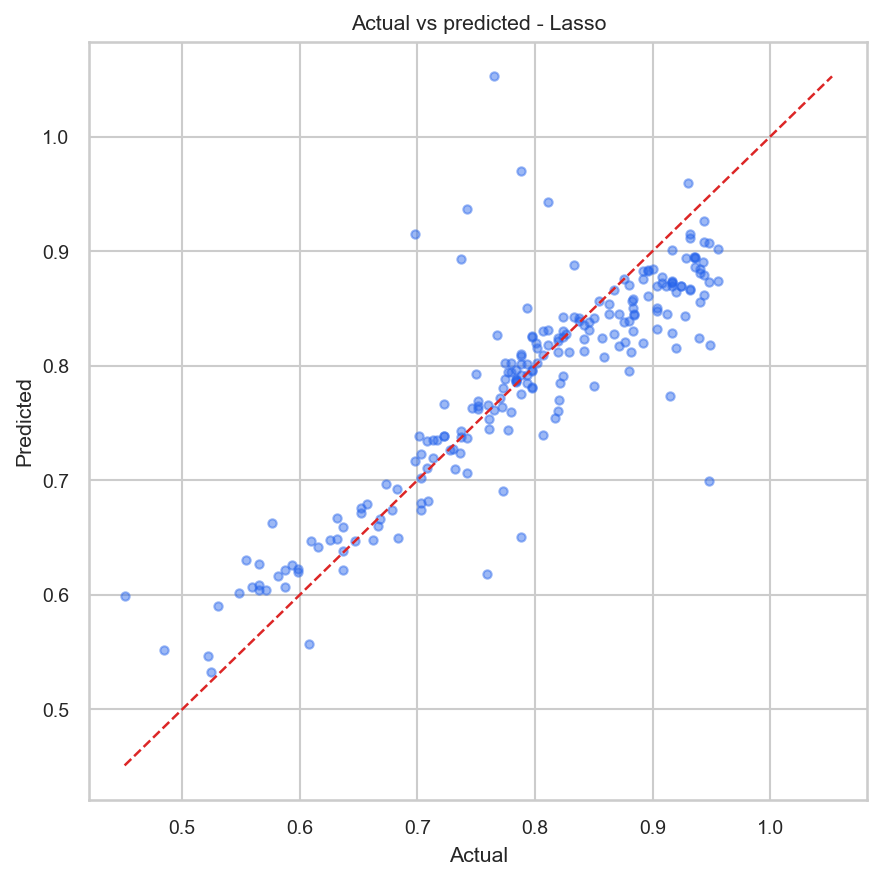

In [19]:
display(Image(filename=str(OUT_DIR / "actual_vs_predicted.png")))


Actual vs Predicted của mô hình tốt nhất nằm khá sát đường chéo, nghĩa là dự báo nhìn chung bám tốt giá trị thực. Các điểm lệch khỏi đường chéo là phần mà mô hình tuyến tính/log-linear chưa giải thích được hoàn toàn.


## 6. Đánh giá mô hình (Evaluation)

### 6.1 So sánh 4 mô hình


,model,test_MAE,test_RMSE,test_R2,cv_MSE,cv_R2
0,Lasso,0.037895,0.056872,0.748403,0.005074,0.673462
1,OLS full,0.037952,0.056941,0.747794,0.005075,0.673407
2,Ridge,0.038204,0.056954,0.747678,0.005074,0.673433
3,OLS selected,0.039013,0.057378,0.743913,0.005103,0.671611


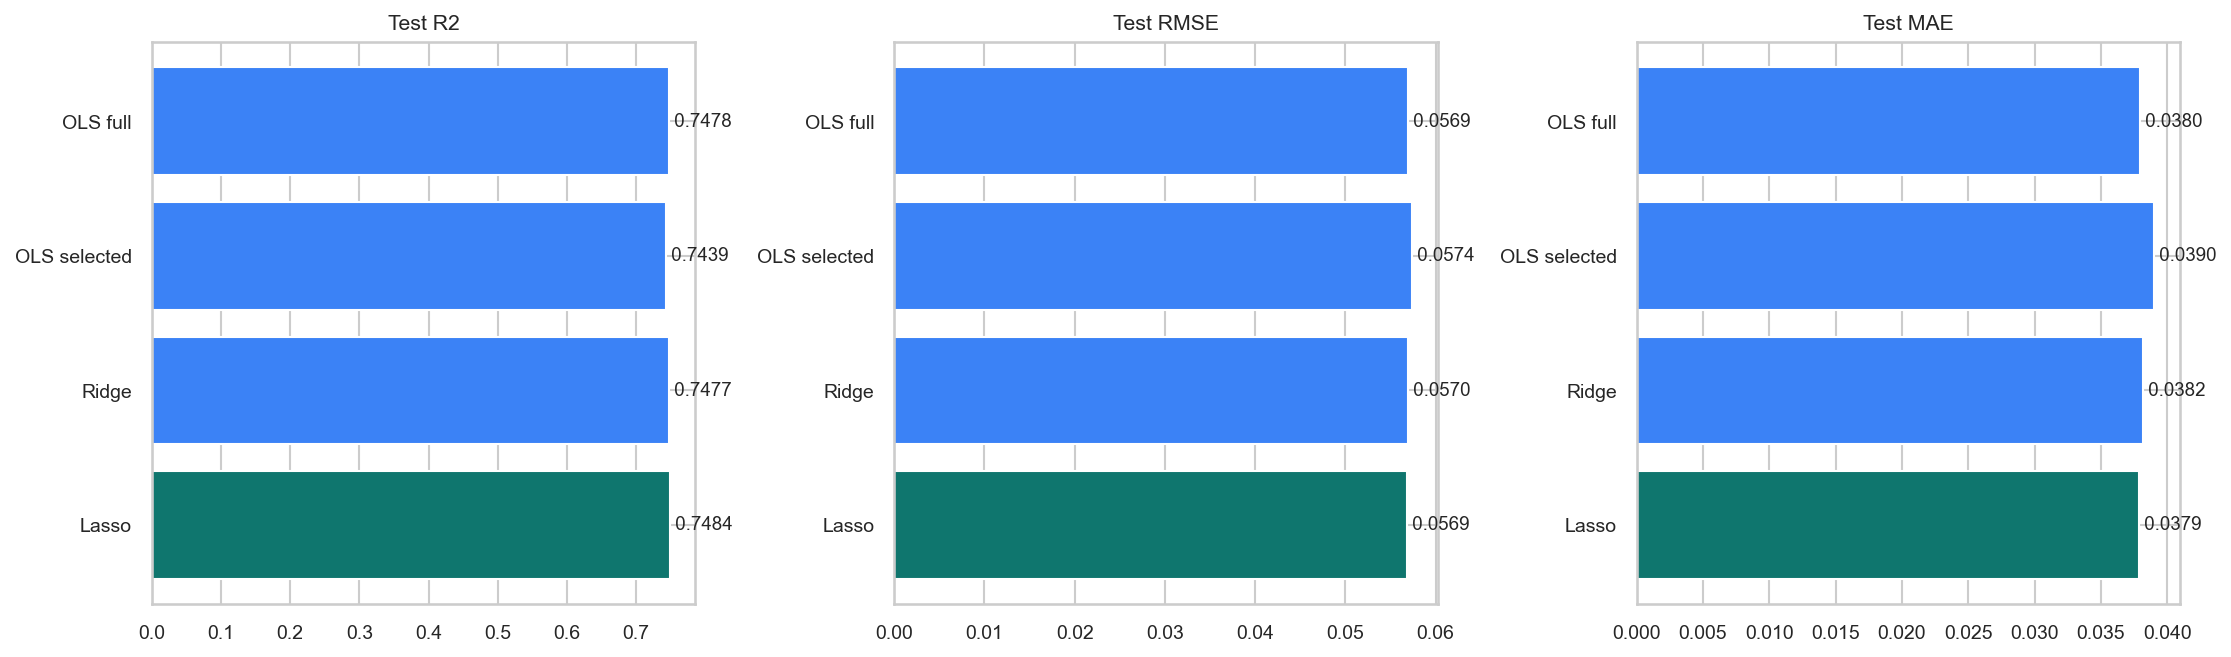

In [20]:
display(summary[["model", "test_MAE", "test_RMSE", "test_R2", "cv_MSE", "cv_R2"]].round(6))
display(Image(filename=str(OUT_DIR / "model_comparison.png")))


Lasso đang nhỉnh nhất theo R2 test, nhưng OLS full và Ridge rất gần nhau. Điều này cho thấy sau khi pipeline đã xử lý skewness, missing values, outlier và VIF, tín hiệu còn lại tương đối tuyến tính; regularization chỉ cải thiện nhẹ chứ không tạo khác biệt lớn.


### 6.2 Feature importance


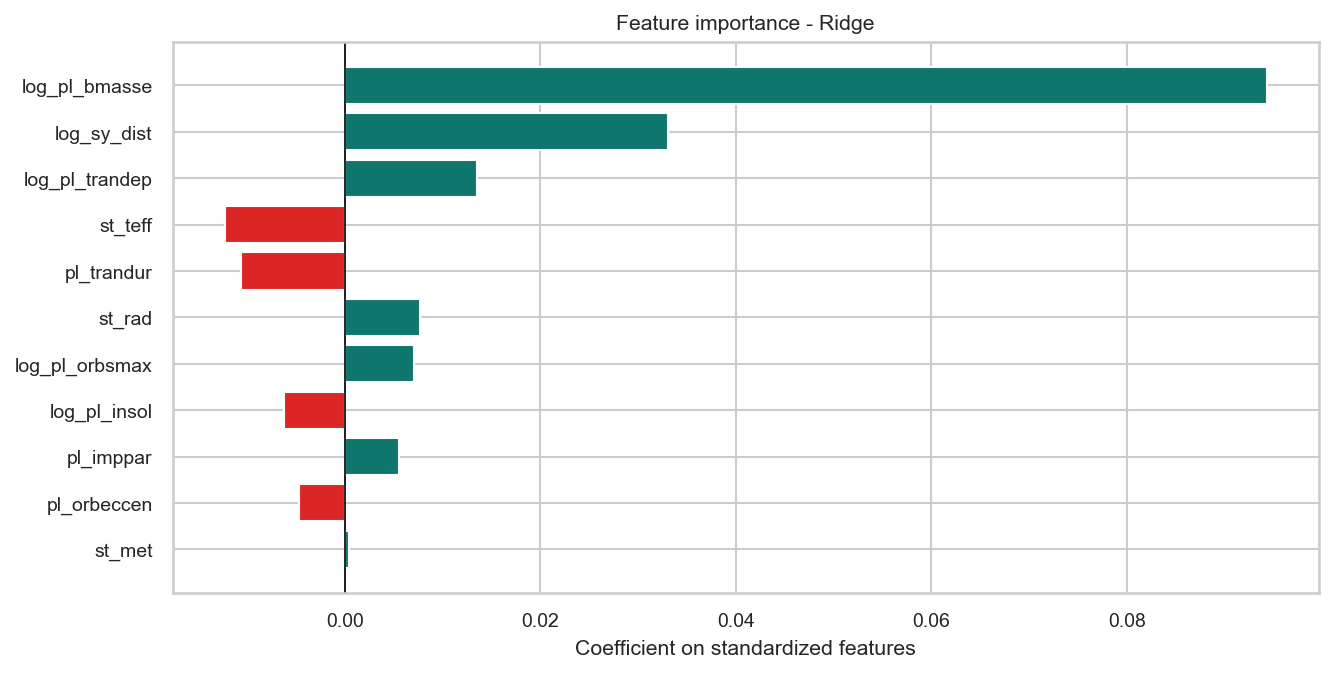

,feature,coef
9,log_pl_bmasse,0.094292
10,log_sy_dist,0.033049
7,log_pl_trandep,0.013552
3,st_teff,-0.012273
1,pl_trandur,-0.010632
4,st_rad,0.007749
6,log_pl_orbsmax,0.007139
8,log_pl_insol,-0.006234
2,pl_imppar,0.005601
0,pl_orbeccen,-0.004702


In [21]:
display(Image(filename=str(OUT_DIR / "feature_importance.png")))

ridge = fitted["results"]["Ridge"]
ridge_coef = pd.DataFrame(
    {
        "feature": ridge["feature_names"],
        "coef": ridge["model"]["beta_hat"][1:],
    }
)
ridge_coef["abs_coef"] = ridge_coef["coef"].abs()
display(ridge_coef.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").round(6))


Hệ số Ridge được đọc trên feature đã chuẩn hóa, nên độ lớn tuyệt đối phản ánh mức ảnh hưởng tương đối. `log_pl_bmasse` thường là biến mạnh nhất vì khối lượng liên quan trực tiếp tới kích thước hành tinh. `log_sy_dist` cũng quan trọng nhưng cần diễn giải cẩn thận: khoảng cách tới hệ sao có thể phản ánh selection bias của dữ liệu quan sát, vì các hệ xa/gần không được phát hiện và đo lường theo cùng một cơ chế hoàn toàn ngẫu nhiên.


### 6.3 Phân tích phần dư


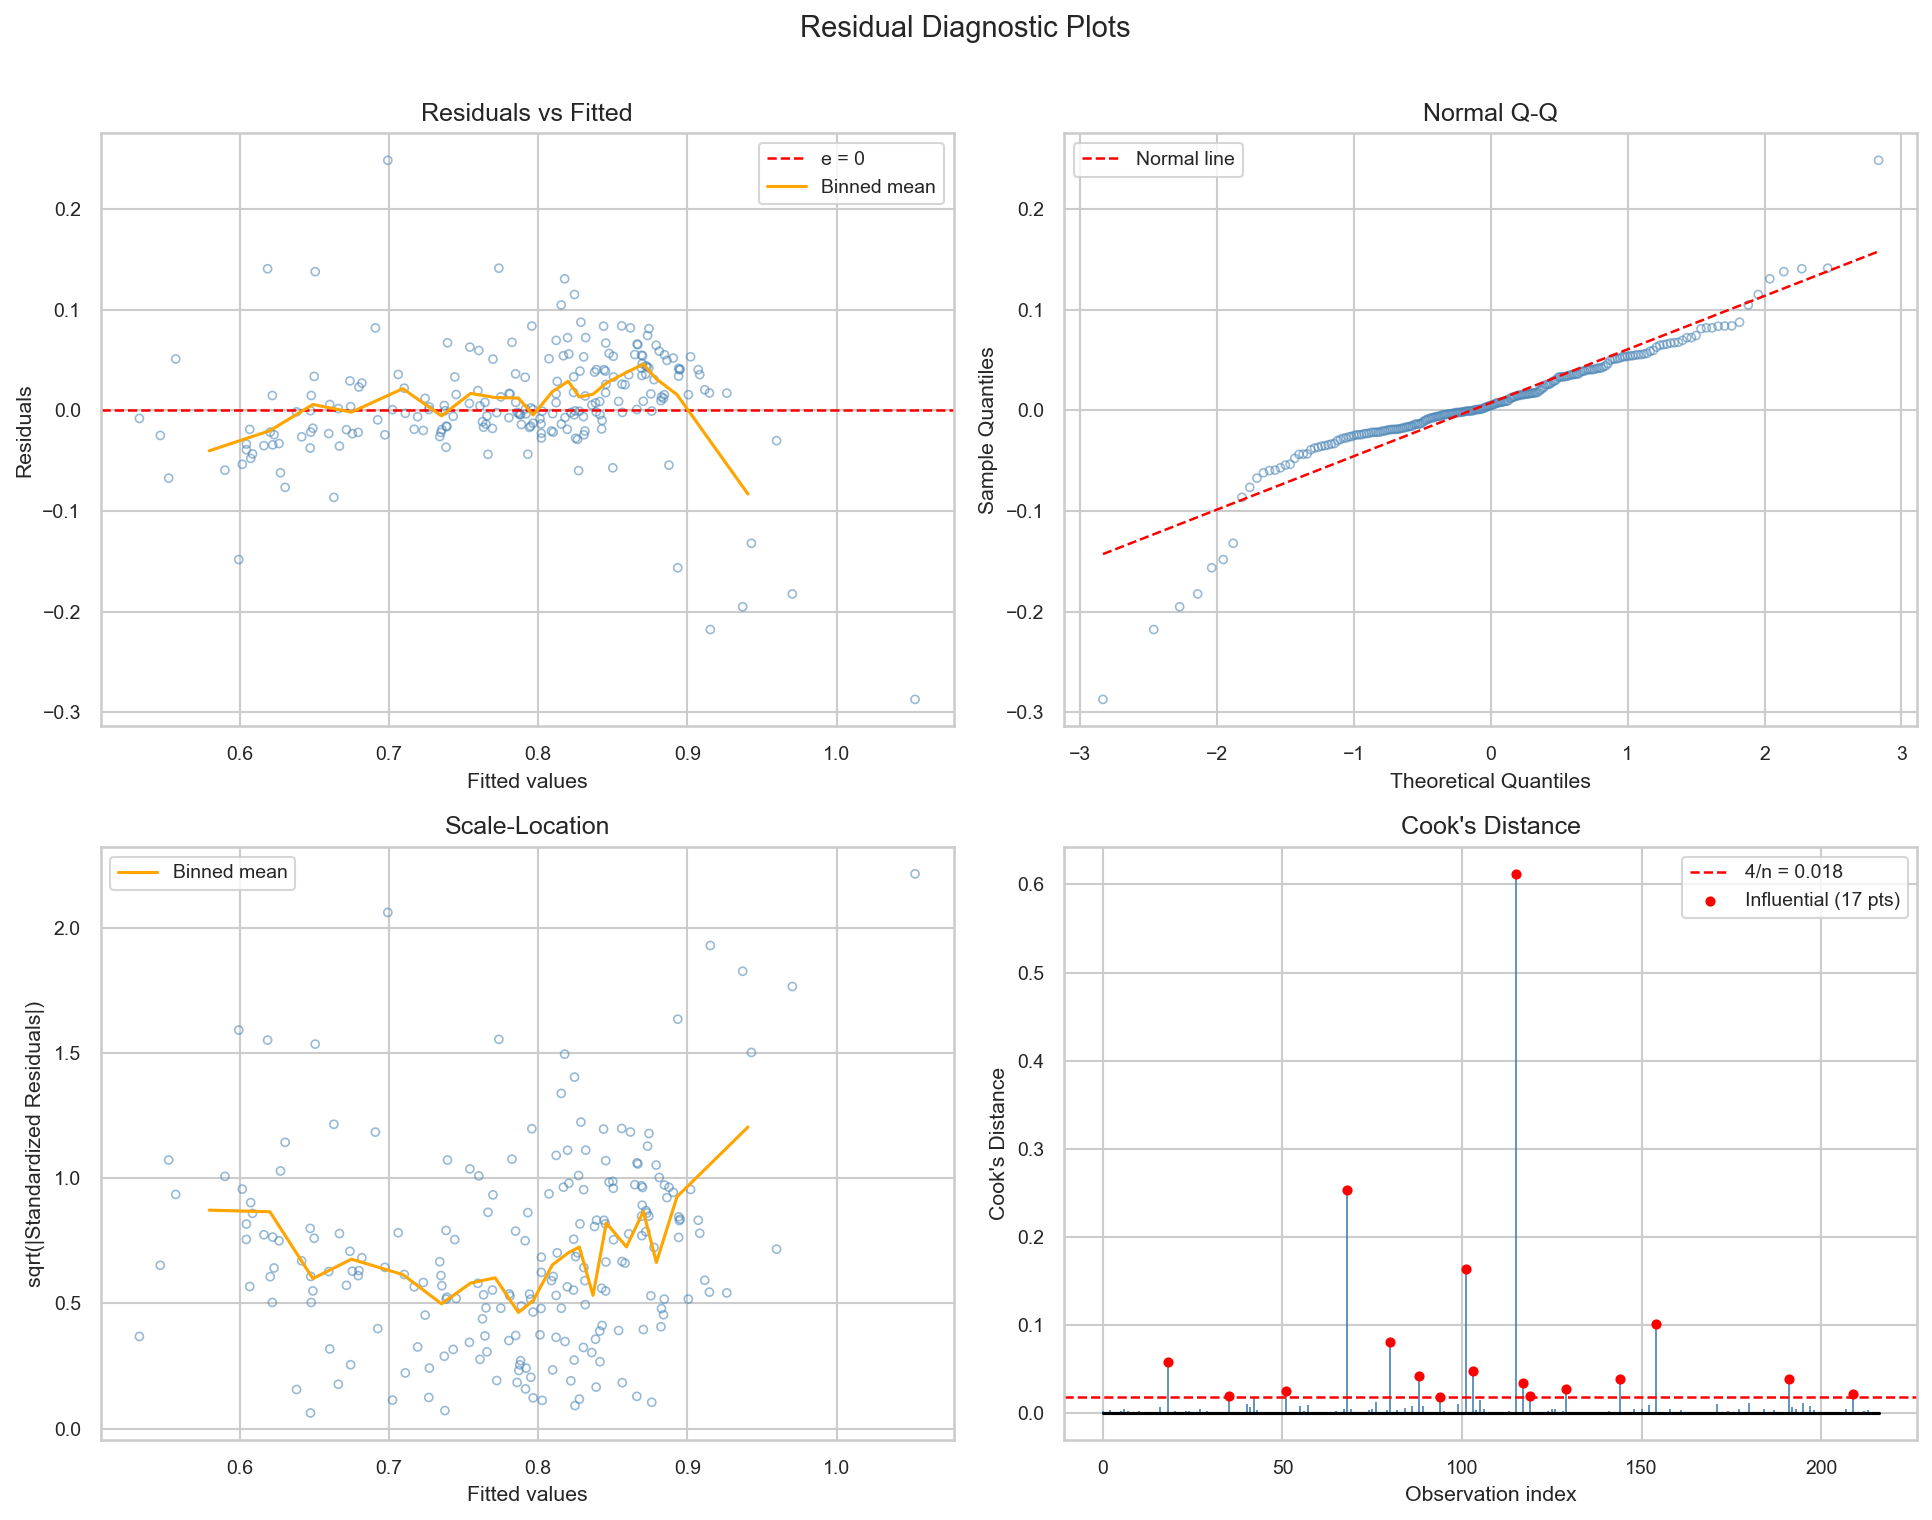

,metric,value,note
0,residual_mean,0.007631,Mean residual should be near 0
1,residual_std,0.056358,Residual spread on log target scale
2,max_abs_standardized_residual,4.907863,Large values mark tail/outlier behavior
3,cook_threshold_4_over_n,0.018433,Reference line used in Cook distance plot
4,cook_points_above_threshold,17.000000,Potentially influential observations


In [22]:
best_features = best_result["feature_names"]
X_test_best = fitted["X_test"][best_features].astype(float).values.tolist()

residual_info = residual_plots(
    y_test_log.tolist(),
    y_pred_log.tolist(),
    X=X_test_best,
    save_dir=str(OUT_DIR),
    show_plot=False,
)
display(Image(filename=residual_info["out_path"]))

residuals = residual_info["residuals"]
std_residuals = residual_info["std_residuals"]
cooks_d = residual_info["cooks_d"]
cook_threshold = 4 / len(cooks_d)

def _mean(values):
    return sum(values) / len(values) if values else 0.0

def _std(values):
    avg = _mean(values)
    return math.sqrt(sum((value - avg) ** 2 for value in values) / len(values)) if values else 0.0

diagnostic_summary = pd.DataFrame(
    [
        {
            "metric": "residual_mean",
            "value": _mean(residuals),
            "note": "Mean residual should be near 0",
        },
        {
            "metric": "residual_std",
            "value": _std(residuals),
            "note": "Residual spread on log target scale",
        },
        {
            "metric": "max_abs_standardized_residual",
            "value": max(abs(value) for value in std_residuals),
            "note": "Large values mark tail/outlier behavior",
        },
        {
            "metric": "cook_threshold_4_over_n",
            "value": cook_threshold,
            "note": "Reference line used in Cook distance plot",
        },
        {
            "metric": "cook_points_above_threshold",
            "value": sum(value > cook_threshold for value in cooks_d),
            "note": "Potentially influential observations",
        },
    ]
)
display(diagnostic_summary.round(6))


Bản diagnostic plots cho thấy mô hình tuyến tính mô tả được xu hướng trung tâm nhưng các giả định Gauss-Markov không hoàn toàn lý tưởng.

* **Residuals vs Fitted:** Phần lớn phần dư dao động quanh đường $e = 0$, nên giả định trung bình có điều kiện bằng 0 (GM1) nhìn chung chấp nhận được. Tuy nhiên, đường LOWESS không hoàn toàn nằm ngang: ở vùng fitted khoảng 0.82 - 0.90 phần dư có xu hướng dương, còn ở vùng fitted cao hơn lại giảm mạnh. Điều này gợi ý mô hình còn thiếu một phần cấu trúc phi tuyến hoặc tương tác.
* **Normal Q-Q:** Các điểm ở vùng giữa bám khá sát đường chuẩn, nhưng hai đuôi lệch rõ, đặc biệt đuôi trái có vài residual âm rất lớn. Vì vậy, giả định chuẩn của phần dư (GM5, nếu dùng cho suy luận mẫu nhỏ) chỉ đúng xấp xỉ; p-value Shapiro-Wilk nhỏ cũng ủng hộ nhận xét này.
* **Scale-Location:** Đường LOWESS không phẳng vì độ lớn phần dư tăng lại ở vùng fitted cao. Điều này là dấu hiệu phương sai phần dư chưa hoàn toàn đồng nhất, tức GM4 (homoskedasticity) bị vi phạm nhẹ đến vừa. Kết quả Breusch-Pagan có p-value nhỏ cũng gợi ý heteroskedasticity.
* **Cook's Distance:** Có 17 điểm vượt ngưỡng $4/n$, trong đó một điểm có Cook's distance rất lớn so với phần còn lại. Các điểm này có ảnh hưởng đáng kể đến mô hình, nhưng nhóm không xóa vì đây có thể là quan sát thiên văn hợp lý sau domain restriction, không phải lỗi nhập liệu rõ ràng.

### 6.4 Kiểm chứng giả thuyết Giãn nở nhiệt (Thermal Expansion Hypothesis)

**Kiểm định tác động tương tác giữa Khối lượng và Nhiệt độ:**

Từ đường cong trên biểu đồ Residuals vs Fitted, nhóm đặt giả thuyết rằng tác động của khối lượng lên bán kính có thể bị chi phối bởi mức độ bức xạ nhiệt, tức một dạng hiệu ứng giãn nở nhiệt.

Thực nghiệm đầu tiên bổ sung biến tương tác

$$\text{Khối lượng} \times \text{Nhiệt độ sao chủ}
= \texttt{log\_pl\_bmasse} \times \texttt{st\_teff}.$$

Kết quả cho thấy p-value của biến tương tác bằng $0.098 > 0.05$, nên biến này không có ý nghĩa thống kê ở mức ý nghĩa $\alpha = 0.05$. Nguyên nhân hợp lý là nhiệt độ sao chủ không phản ánh đúng nhiệt lượng hành tinh thực nhận nếu bỏ qua khoảng cách quỹ đạo.

Khi thay nhiệt độ sao chủ bằng bức xạ thực nhận, tức bổ sung biến tương tác

$$\text{Khối lượng} \times \text{Bức xạ thực nhận}
= \texttt{log\_pl\_bmasse} \times \texttt{log\_pl\_insol},$$

biến tương tác có ý nghĩa rất mạnh trên tập huấn luyện với p-value xấp xỉ 0. Tuy nhiên, hiệu năng ngoại suy lại suy giảm: $R^2_{\text{Test}}$ giảm từ khoảng $0.747$ xuống khoảng $0.741$. Điều này cho thấy biến tương tác tạo ra đa cộng tuyến cấu trúc (structural multicollinearity) và làm mô hình quá khớp với train set.

Kết luận rút ra là việc cố gắng bẻ cong mặt phẳng OLS bằng biến tương tác để sửa lỗi phần dư cục bộ đã phá vỡ tính tổng quát hóa của mô hình. Điều này củng cố nguyên lý Occam's Razor: mô hình OLS cơ bản hiện tại, không chứa biến tương tác, là điểm cân bằng hợp lý hơn giữa phương sai (variance) và độ chệch (bias).


### 6.5 Kernel Ridge (bonus)


In [23]:
advanced = run_kernel_ridge_bonus(OUT_DIR / "preprocessed.pkl", OUT_DIR, max_train=200)
display(pd.DataFrame([advanced["best_on_test"]]).round(6))

kernel_search_path = OUT_DIR / "kernel_ridge_search.csv"
if kernel_search_path.exists():
    display(pd.read_csv(kernel_search_path).sort_values("Val_RMSE").head(10).round(6))


Best validation params: {'alpha': 0.01, 'gamma': 0.01}


,alpha,gamma,MAE,RMSE,R2
0,0.01,0.01,0.038842,0.062023,0.700766


,alpha,gamma,Val_RMSE
0,0.010,0.010,0.071636
1,0.100,0.010,0.075317
2,0.001,0.010,0.075770
3,0.001,0.001,0.080698
4,1.000,0.010,0.084010
5,0.010,0.001,0.089867
6,0.100,0.001,0.091168
7,0.010,0.050,0.091262
8,0.100,0.050,0.093993
9,0.001,0.050,0.095335


Kernel Ridge dùng RBF kernel như phần bonus để kiểm tra tín hiệu phi tuyến. Kết quả chỉ dùng tối đa 200 mẫu train do ma trận kernel tăng kích thước nhanh, nên không so sánh trực tiếp như một mô hình chính thức với bốn mô hình tuyến tính ở trên.


## 7. Kết luận

Pipeline tiền xử lý giúp đưa dữ liệu ngoại hành tinh về dạng phù hợp cho hồi quy: giảm lệch phân phối bằng log-transform, giới hạn outlier bằng Winsorization, điền missing values bằng MICE, xử lý đa cộng tuyến bằng VIF và chuẩn hóa feature.

Trong bốn mô hình chính, Lasso nhỉnh nhất trên test set nhưng OLS full và Ridge gần như tương đương. Điều này cho thấy phần lớn tín hiệu sau tiền xử lý có thể được mô tả khá tốt bằng quan hệ tuyến tính/log-linear. Tuy nhiên R2 test khoảng 0.75 nghĩa là vẫn còn khoảng 25% biến thiên chưa được giải thích.

Hạn chế chính là dữ liệu quan sát có selection bias, missing values và khả năng phi tuyến vật lý chưa được mô hình tuyến tính nắm bắt đầy đủ. Hướng cải thiện hợp lý là bổ sung biến vật lý/quan sát khác, kiểm tra mô hình phi tuyến một cách có kiểm soát và đánh giá độ bất định của dự báo trên thang gốc.
